In [36]:
import torch
import os
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

## Dataset information

In [37]:
ATTRIBUTES_IDX_USED = [1, 4, 6, 7, 10, 14, 15, 20, 21, 23, 25, 29, 30, 35, 36, 38, 40, 44, 45, 50, 51, 53, 54, 56, 57, 59, 63, 64, 69, 70, 72, 75, 80, 84, 90, 91, \
    93, 99, 101, 106, 110, 111, 116, 117, 119, 125, 126, 131, 132, 134, 145, 149, 151, 152, 153, 157, 158, 163, 164, 168, 172, 178, 179, 181, \
    183, 187, 188, 193, 194, 196, 198, 202, 203, 208, 209, 211, 212, 213, 218, 220, 221, 225, 235, 236, 238, 239, 240, 242, 243, 244, 249, 253, \
    254, 259, 260, 262, 268, 274, 277, 283, 289, 292, 293, 294, 298, 299, 304, 305, 308, 309, 310, 311]

with open(os.path.join("datasets", "CUB", "CUB_200_2011", "attributes.txt"), 'r') as f:
    all_attributes_orig_idx = {}
    
    lines = f.readlines()
    for line in lines:
        idx, attr_name = line.strip().split(" ")
        #attr_group, attr_name = attr_name.split("::")  
        # 0-based indexing
        all_attributes_orig_idx[int(idx) - 1] = attr_name
  
# Map between 112 concept idx and attribute name      
sample_112_concepts_map = {new_idx: all_attributes_orig_idx[orig_idx] for new_idx, orig_idx in enumerate(ATTRIBUTES_IDX_USED)}
attr_groups__112_concepts = list(set(attr_name.split("::")[0] for attr_name in sample_112_concepts_map.values()))

print(sample_112_concepts_map)
print(attr_groups__112_concepts)
print(len(attr_groups__112_concepts))


{0: 'has_bill_shape::dagger', 1: 'has_bill_shape::hooked_seabird', 2: 'has_bill_shape::all-purpose', 3: 'has_bill_shape::cone', 4: 'has_wing_color::brown', 5: 'has_wing_color::grey', 6: 'has_wing_color::yellow', 7: 'has_wing_color::black', 8: 'has_wing_color::white', 9: 'has_wing_color::buff', 10: 'has_upperparts_color::brown', 11: 'has_upperparts_color::grey', 12: 'has_upperparts_color::yellow', 13: 'has_upperparts_color::black', 14: 'has_upperparts_color::white', 15: 'has_upperparts_color::buff', 16: 'has_underparts_color::brown', 17: 'has_underparts_color::grey', 18: 'has_underparts_color::yellow', 19: 'has_underparts_color::black', 20: 'has_underparts_color::white', 21: 'has_underparts_color::buff', 22: 'has_breast_pattern::solid', 23: 'has_breast_pattern::striped', 24: 'has_breast_pattern::multi-colored', 25: 'has_back_color::brown', 26: 'has_back_color::grey', 27: 'has_back_color::yellow', 28: 'has_back_color::black', 29: 'has_back_color::white', 30: 'has_back_color::buff', 31: '

In [38]:
# Read dataset dir from the log file in the experiment path
import ast


info_dataset_path = os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", "info.txt")


with open(info_dataset_path, 'r') as f:
    lines = f.readlines()

    for line in lines:
        if "New attribute indices mapping: " in line:
            new_attribute_mapping_string = line.split("New attribute indices mapping: ")[1].strip()
            
        if "Removed attribute groups: " in line:
            removed_attribute_groups_string = line.split("Removed attribute groups: ")[1].strip()
            

# Original has 112 attributes, but we only use a subset of them
new_attribute_mapping = ast.literal_eval(new_attribute_mapping_string)

# Removed groups list
removed_attribute_groups = ast.literal_eval(removed_attribute_groups_string)
    

        
        
concept_names_new_idx_map = {}
for orig_idx, new_idx in new_attribute_mapping.items():
    concept_names_new_idx_map[new_idx] = sample_112_concepts_map[orig_idx]


df = pd.DataFrame(list(concept_names_new_idx_map.items()), columns=['New Index', 'Concept Name'])
df.to_csv("delete_afterwards/concept_names_new_idx_map.csv", index=False)
display(df.sort_values(by='New Index').reset_index(drop=True))

# Number of attrbutes removed
print(f"Number of attributes removed: {112 - len(concept_names_new_idx_map.keys())}")





,New Index,Concept Name
0,0,has_bill_shape::dagger
1,1,has_bill_shape::hooked_seabird
2,2,has_bill_shape::all-purpose
3,3,has_bill_shape::cone
4,4,has_head_pattern::eyebrow
5,5,has_head_pattern::plain
6,6,has_breast_color::brown
7,7,has_breast_color::grey
8,8,has_breast_color::yellow
9,9,has_breast_color::black


Number of attributes removed: 90


## Plot train/test/val ground truth distribution

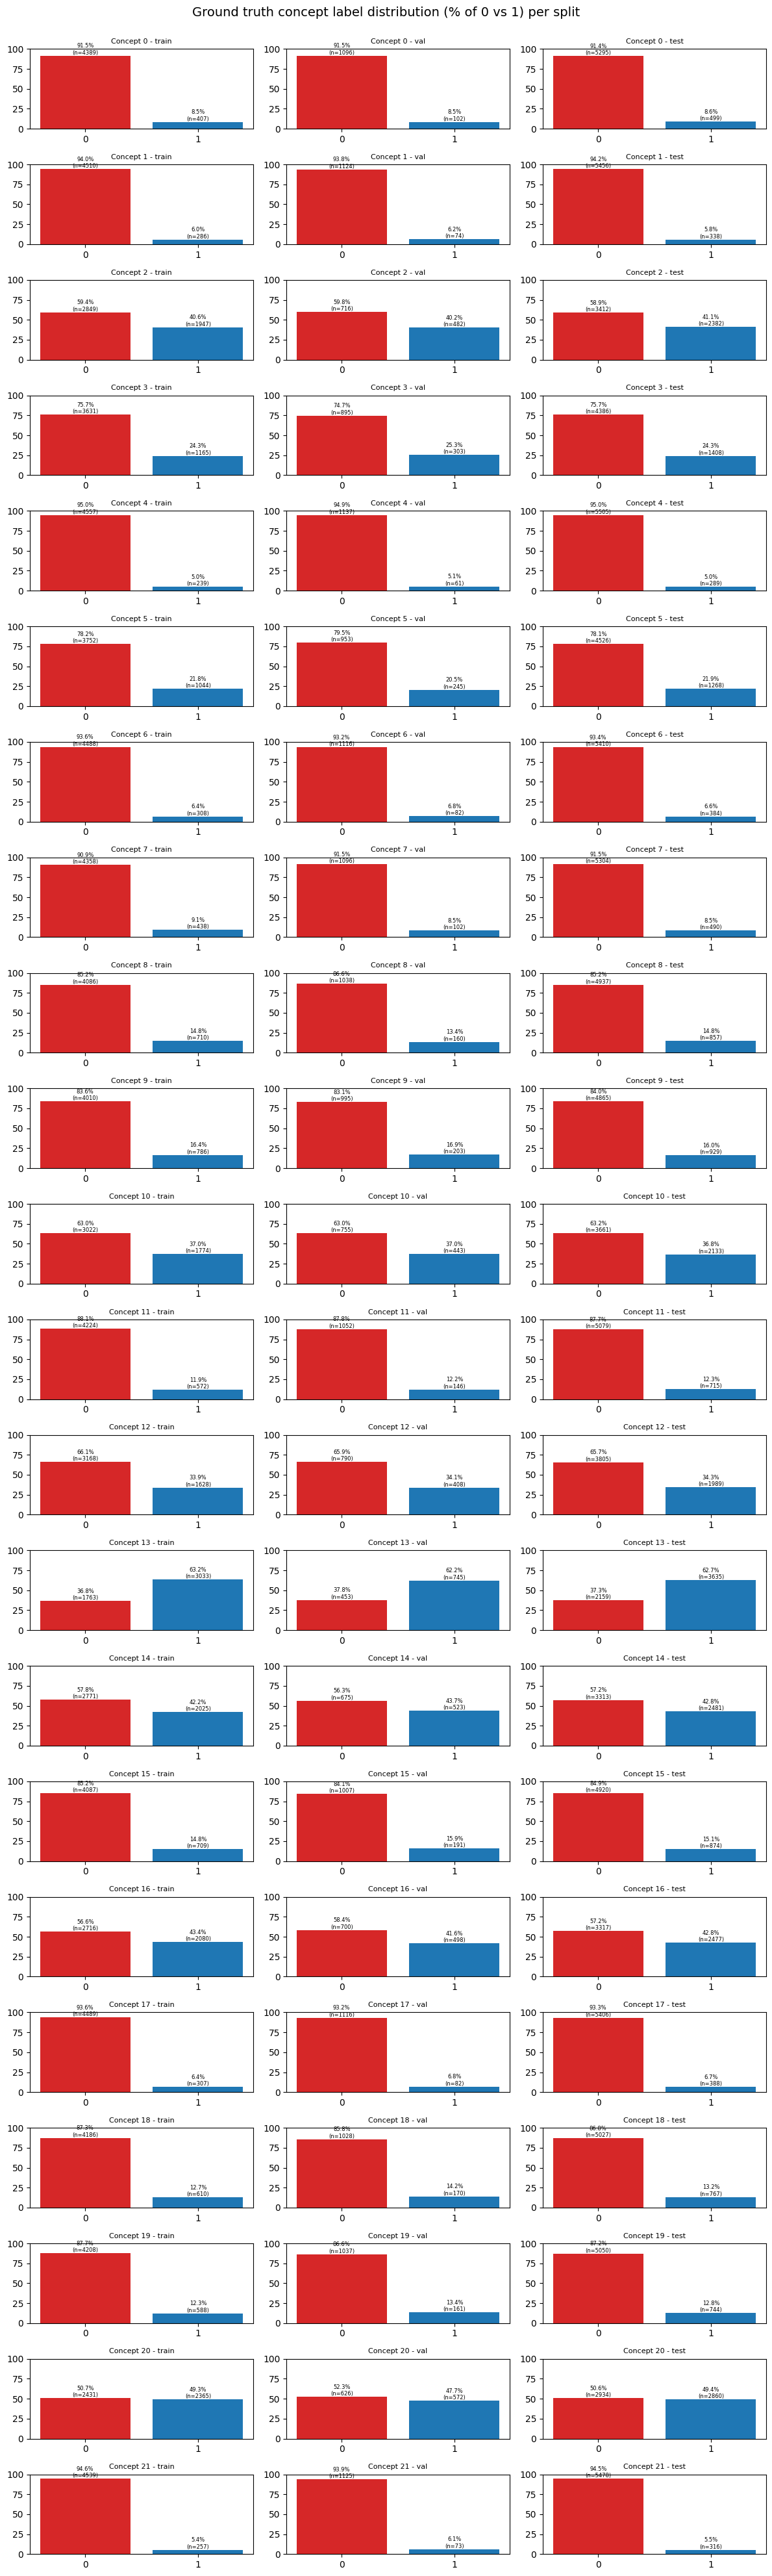

In [39]:
GT_NUM_CONCEPTS = 22
gt_splits = ["train", "val", "test"]

gt_concepts_by_split = {}
for split in gt_splits:
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{split}.pkl"))
    gt_concepts_by_split[split] = np.array([sample["attribute_label"] for sample in data_pkl])

fig, axes = plt.subplots(
    GT_NUM_CONCEPTS, len(gt_splits),
    figsize=(4 * len(gt_splits), 1.8 * GT_NUM_CONCEPTS),
)

for row in range(GT_NUM_CONCEPTS):
    for col, split in enumerate(gt_splits):
        ax = axes[row, col]
        c_true = gt_concepts_by_split[split][:, row]
        n = len(c_true)
        num_ones = int(c_true.sum())
        num_zeros = n - num_ones
        pct_zeros = 100 * num_zeros / n
        pct_ones = 100 * num_ones / n
        ax.bar(["0", "1"], [pct_zeros, pct_ones], color=["tab:red", "tab:blue"])
        ax.set_ylim(0, 100)
        ax.set_title(f"Concept {row} - {split}", fontsize=8)
        for x, (pct, count) in enumerate([(pct_zeros, num_zeros), (pct_ones, num_ones)]):
            ax.text(x, pct, f"{pct:.1f}%\n(n={count})", ha="center", va="bottom", fontsize=6)

fig.suptitle("Ground truth concept label distribution (% of 0 vs 1) per split", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

In [40]:
root_cub = os.path.join("experiments", "scbm_residual", "CUB")

# # 50 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_L_int_extension_loss_weight_1_2026-07-30_17-04-11_72f02")

# # 20 residuals
EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_20_L_int_extension_loss_weight_1_2026-07-31_20-15-47_174e5")

# 5 residuals
# EXPERIMENT_PATH = os.path.join(root_cub, "Mateo_025_fixed_emp_perc_residuals_5_L_int_extension_loss_weight_1_2026-07-31_20-15-47_496cf")



## Residual SCBM distribution plots

In [41]:

NUM_CONCEPTS_CLEAN = 22

train_aug_logits = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_logits_mean.pt"))
train_clean_logits = torch.load(os.path.join(EXPERIMENT_PATH, "train_with_test_transform", "concepts_residuals_logits_mean.pt"))
test_clean_logits = torch.load(os.path.join(EXPERIMENT_PATH, "test", "concepts_residuals_logits_mean.pt"))
test_analysis_logits = torch.load(os.path.join(EXPERIMENT_PATH, "test_analysis", "concepts_residuals_logits_mean.pt"))
val_clean_logits = torch.load(os.path.join(EXPERIMENT_PATH, "val", "concepts_residuals_logits_mean.pt"))

print("train (augmented):", train_aug_logits.shape, "mean", train_aug_logits.mean().item(), "std", train_aug_logits.std().item())
print("train_clean (deterministic):", train_clean_logits.shape, "mean", train_clean_logits.mean().item(), "std", train_clean_logits.std().item())
print("test (deterministic):", test_clean_logits.shape, "mean", test_clean_logits.mean().item(), "std", test_clean_logits.std().item())

num_dims_clean = train_aug_logits.shape[1]


train (augmented): torch.Size([4796, 42]) mean -3.2621009349823 std 12.402484893798828
train_clean (deterministic): torch.Size([4796, 42]) mean -3.6610753536224365 std 13.84461784362793
test (deterministic): torch.Size([5794, 42]) mean -2.62231707572937 std 8.852278709411621


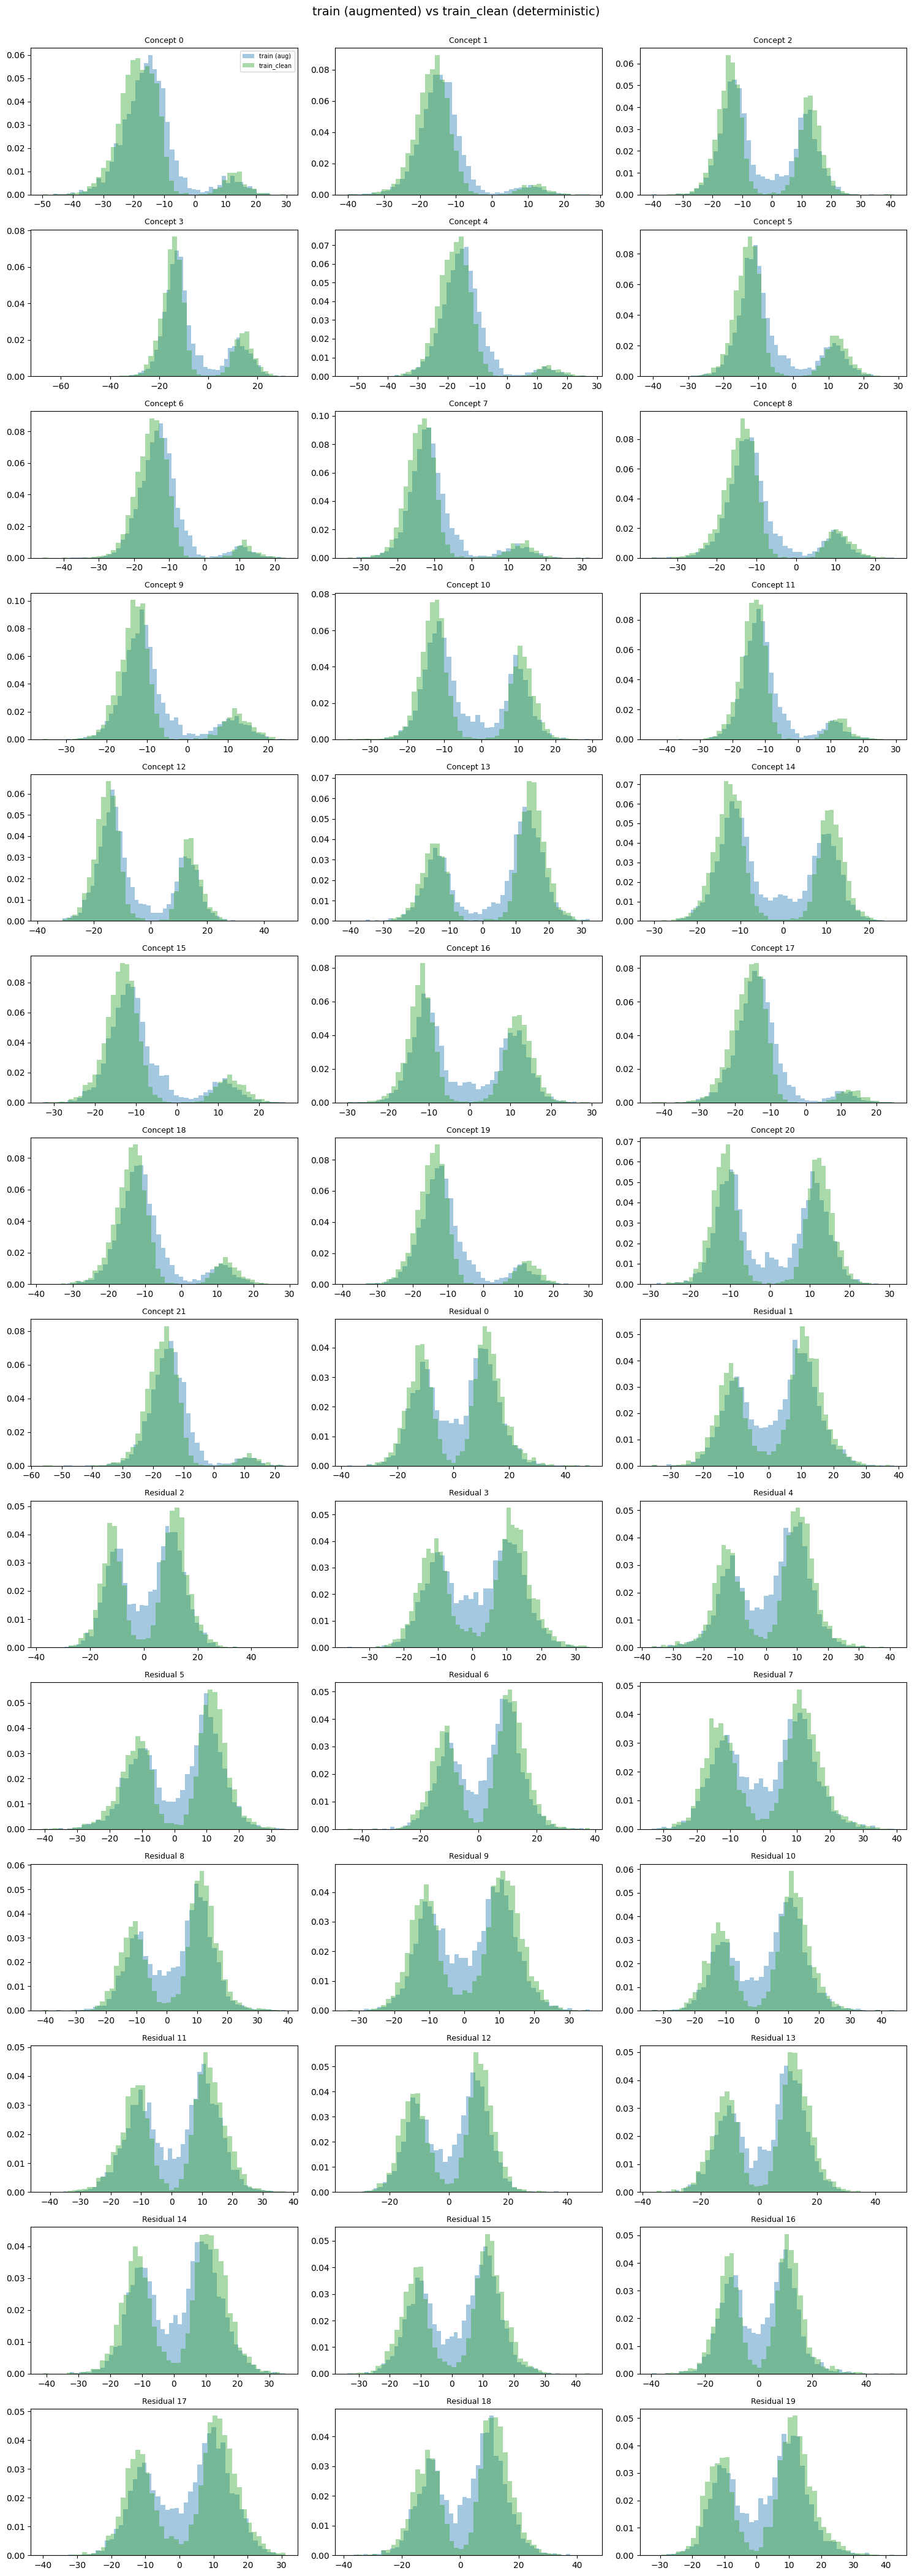

In [42]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("train (augmented) vs train_clean (deterministic)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

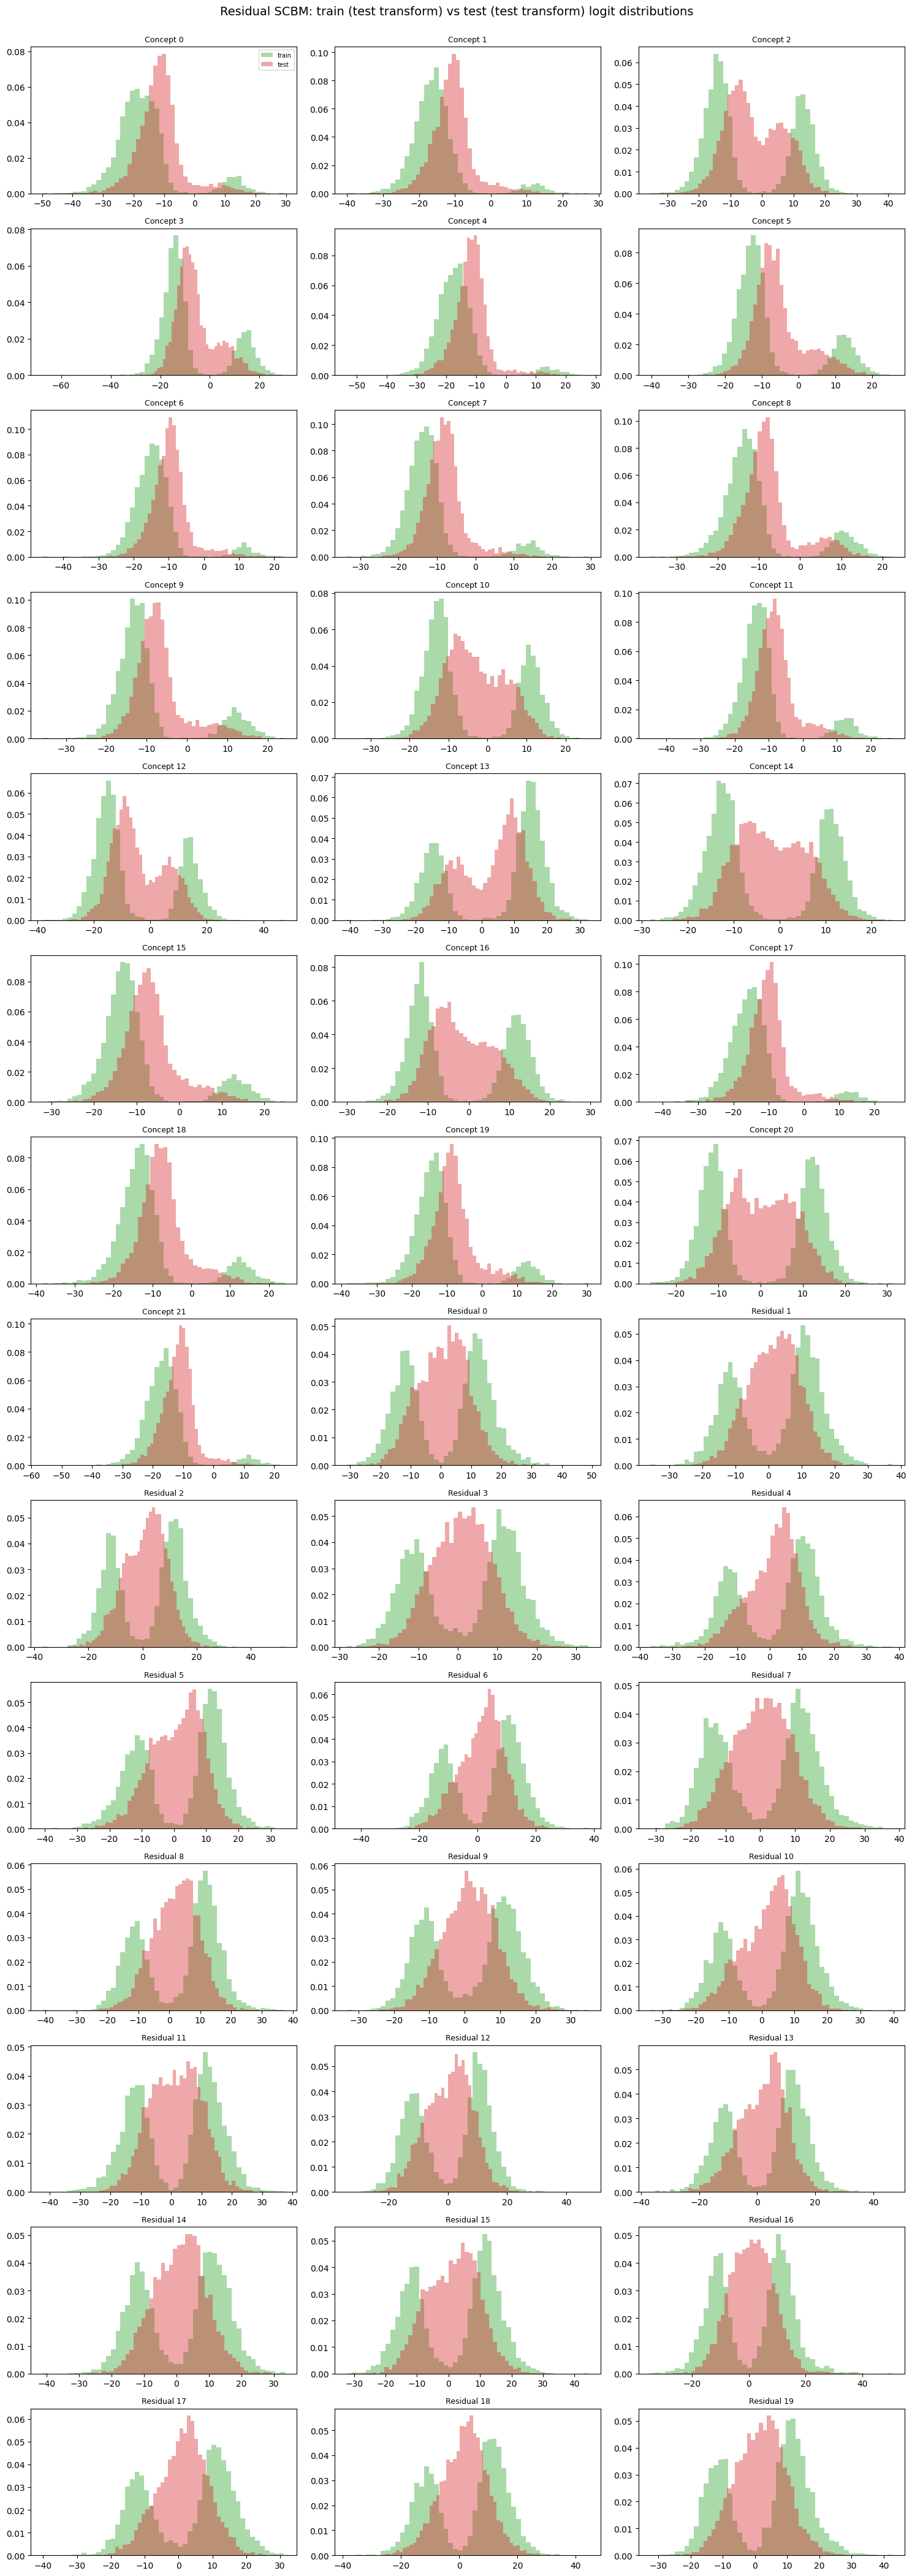

In [43]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("Residual SCBM: train (test transform) vs test (test transform) logit distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

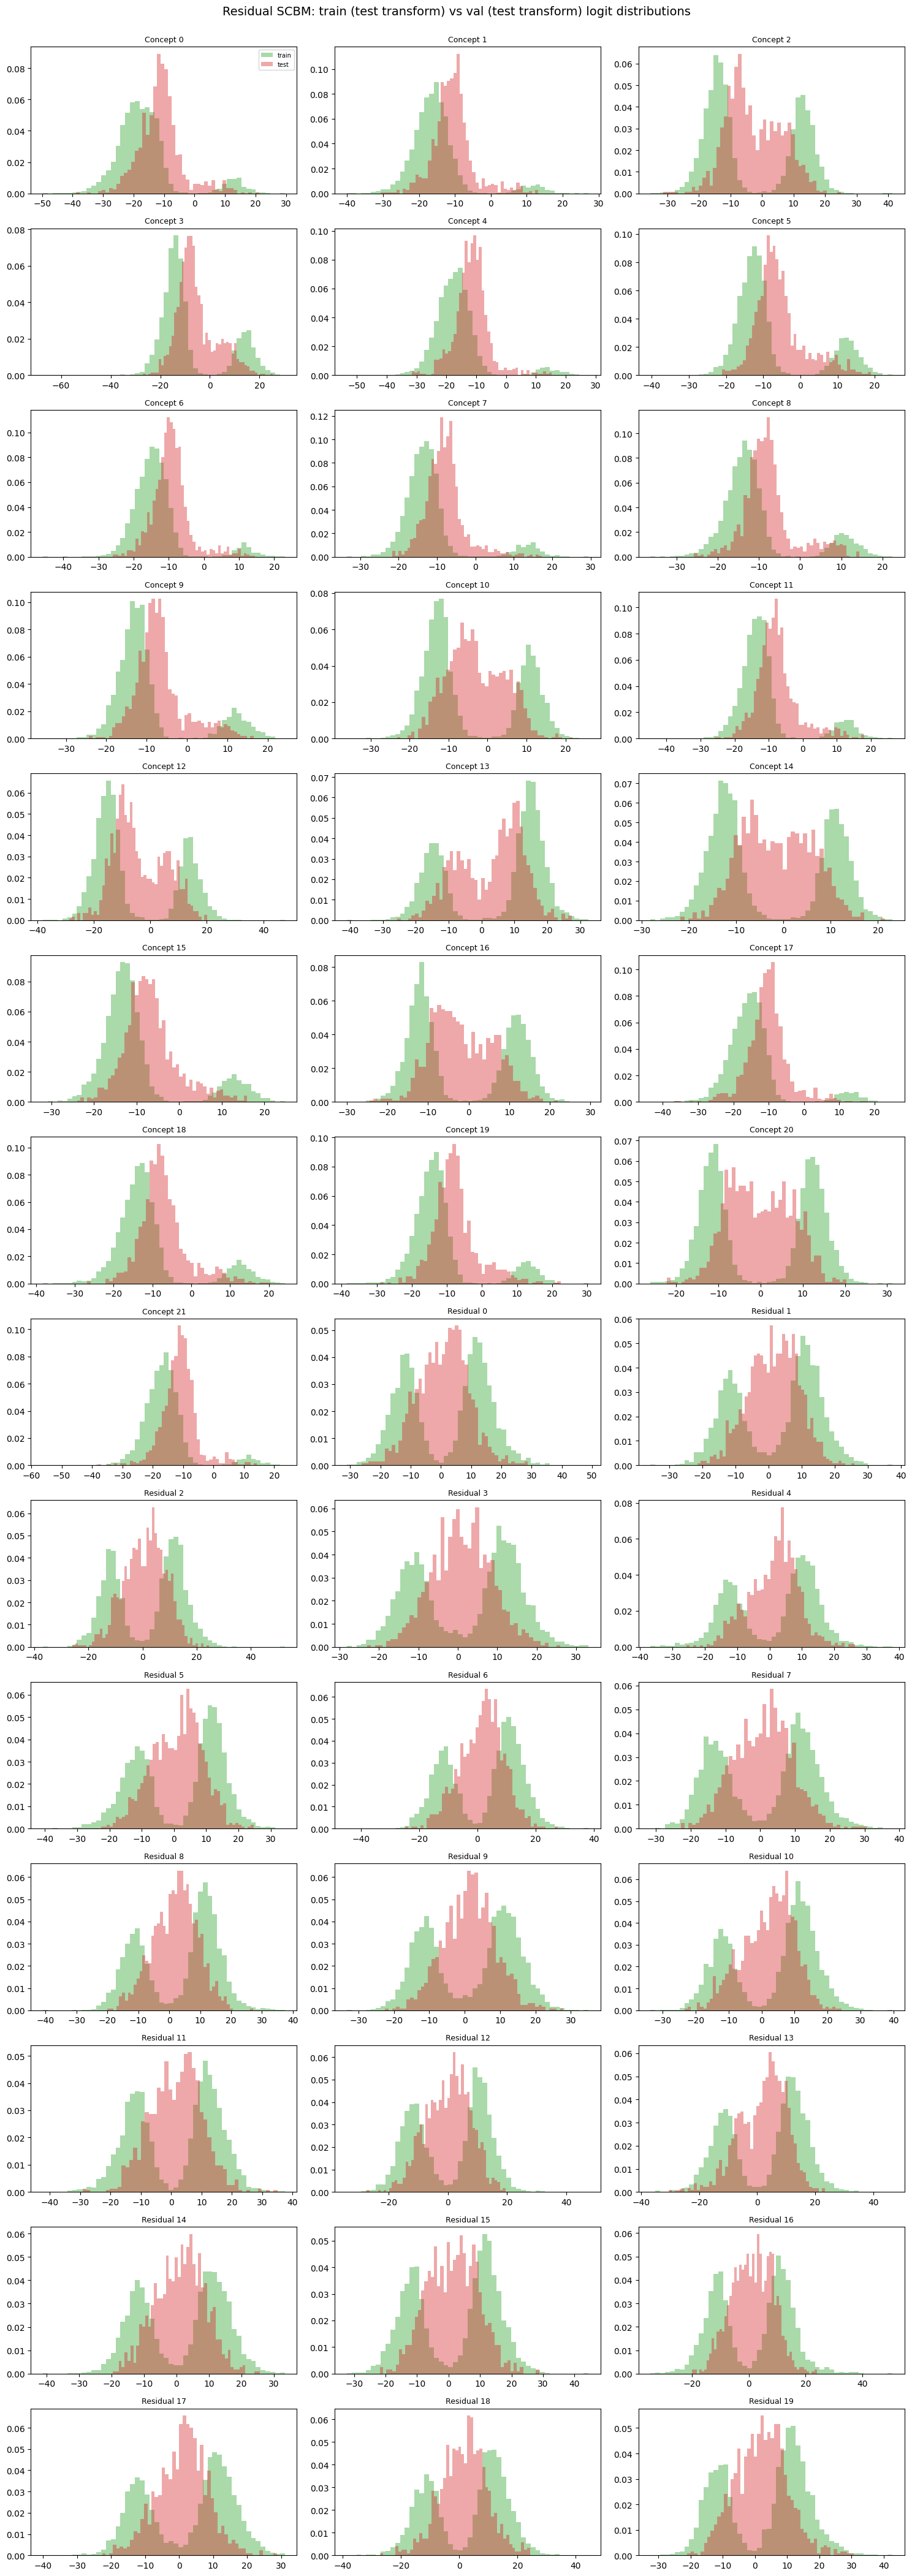

In [44]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(val_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("Residual SCBM: train (test transform) vs val (test transform) logit distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

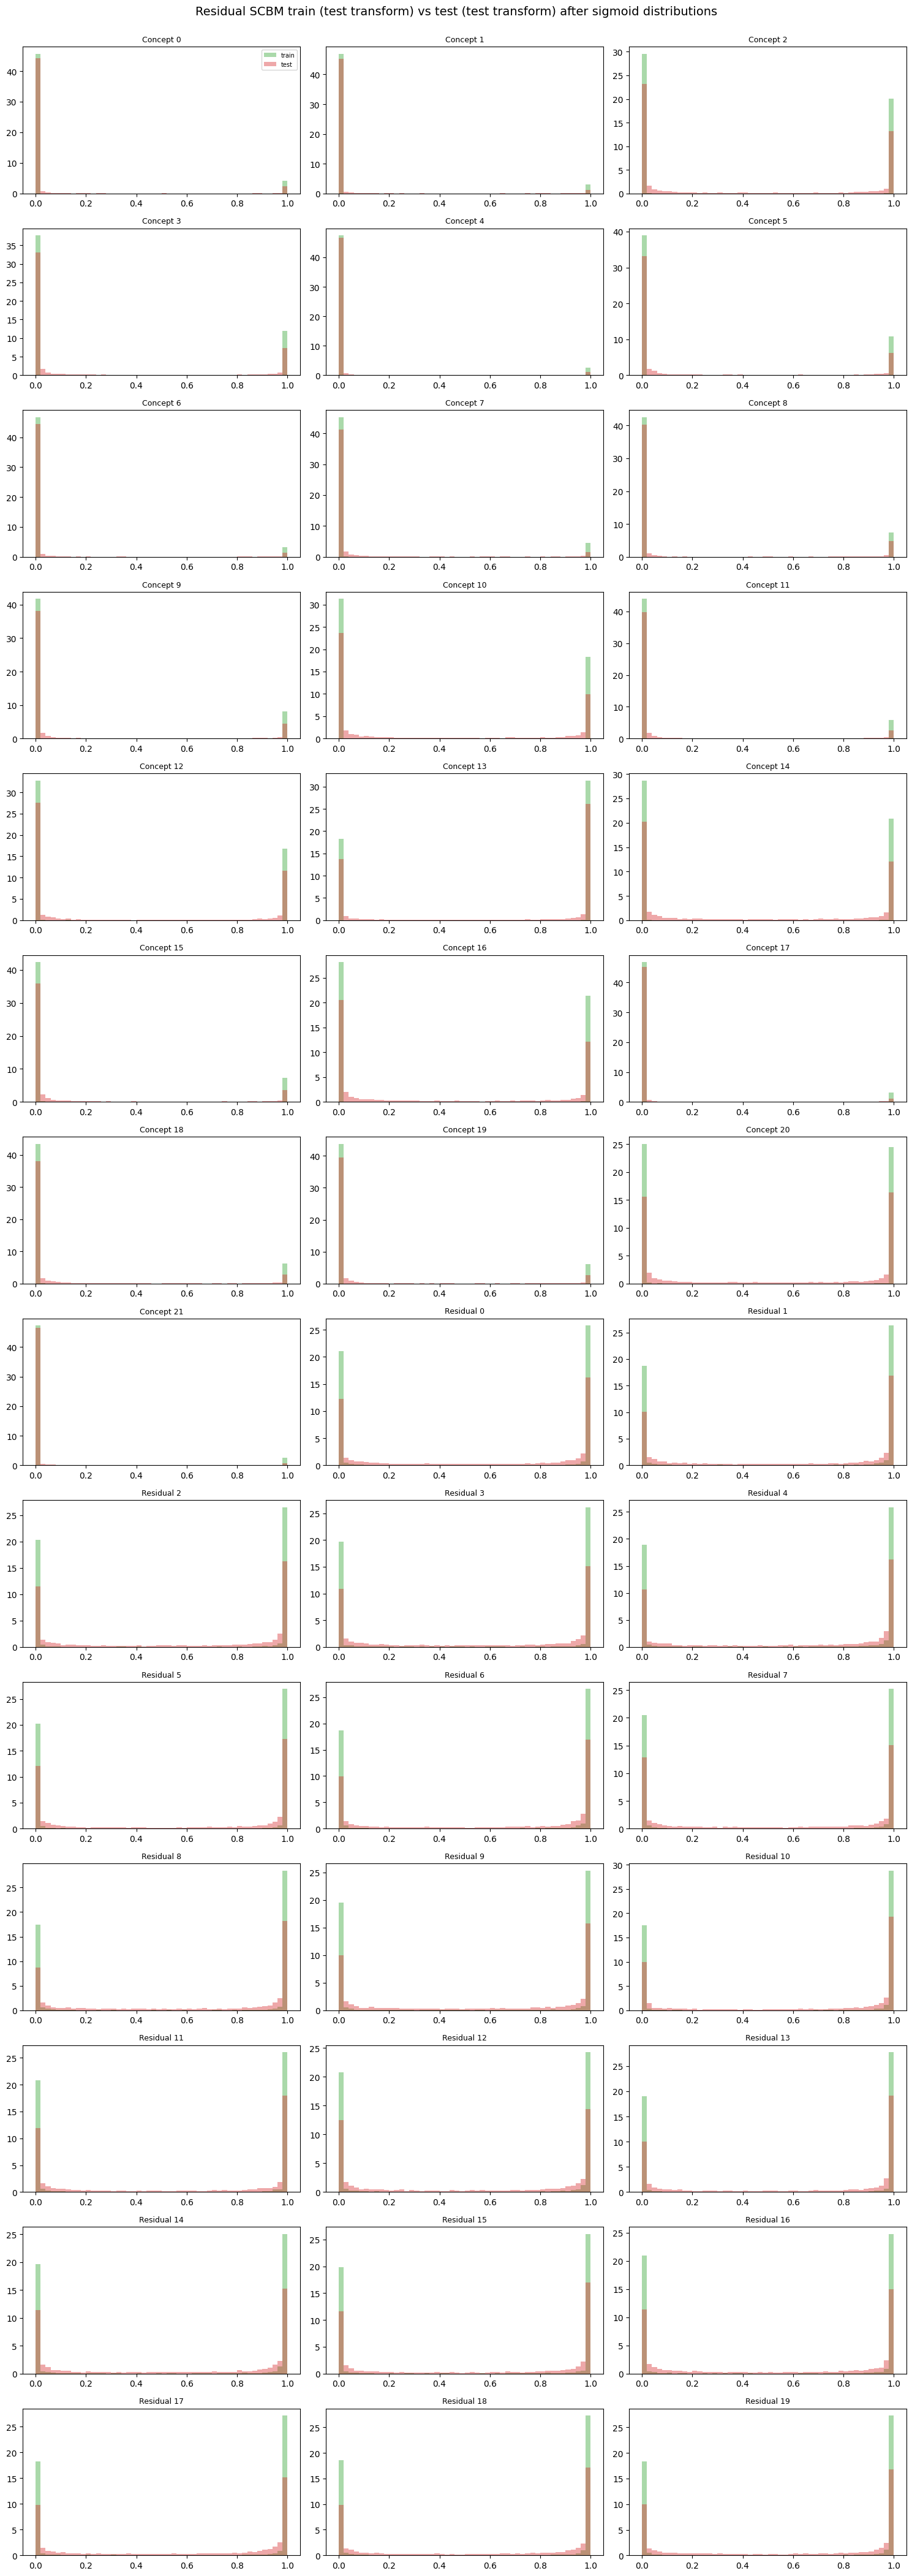

In [45]:
# Do the same for the probabilities (after sigmoid)
# load test probabilities
train_probs = torch.load(os.path.join(EXPERIMENT_PATH, "train", "concepts_residuals_pred_probs_mean.pt"))
train_clean_probs = torch.load(os.path.join(EXPERIMENT_PATH, "train_with_test_transform", "concepts_residuals_pred_probs_mean.pt"))
test_clean_probs = torch.load(os.path.join(EXPERIMENT_PATH, "test", "concepts_residuals_pred_probs_mean.pt"))

# Overlaid histograms:train_clean (deterministic) vs test, per dimension
num_cols = 3
num_rows = math.ceil(num_dims_clean / num_cols) 


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_clean):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CLEAN
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CLEAN}"
    ax.hist(train_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(test_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_clean:]:
    ax.axis("off")

fig.suptitle("Residual SCBM train (test transform) vs test (test transform) after sigmoid distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()


## Concept accuracy and AUROC across splits (including train_clean)

Reproduces `c_accuracy` / `complete_c_accuracy` (`utils/training.py`'s `Custom_Metrics.compute`) and macro-averaged per-concept `c_AUROC` (`utils/metrics.py`'s `calc_concept_metrics`) directly from the saved `concepts_residuals_pred_probs_mean.pt` artifacts, using concept ground truth (`attribute_label`) read from the same pkl files used for the `y_true` order check above. `train_with_test_transform` reuses the train split's pkl (same underlying images, just the deterministic transform instead of augmentation) and uses the same `EXPERIMENT_PATH` as the section above.

In [46]:
from sklearn.metrics import roc_auc_score

CONCEPT_METRICS_NUM_CONCEPTS = 22

splits_to_check = {
    "train": "train",
    "train_with_test_transform": "train",  # same underlying images as train, deterministic transform
    "val": "val",
    "test": "test",
}

concept_metrics_rows = []
for folder_name, pkl_split in splits_to_check.items():
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{pkl_split}.pkl"))
    c_true = np.array([sample["attribute_label"] for sample in data_pkl])

    c_r_probs_split = torch.load(os.path.join(EXPERIMENT_PATH, folder_name, "concepts_residuals_pred_probs_mean.pt"))
    c_pred_probs = c_r_probs_split[:, :CONCEPT_METRICS_NUM_CONCEPTS].numpy()
    c_pred = c_pred_probs > 0.5

    c_accuracy = (c_true == c_pred).mean()
    complete_c_accuracy = (c_true == c_pred).all(axis=1).mean()
    per_concept_auroc = [roc_auc_score(c_true[:, j], c_pred_probs[:, j]) for j in range(CONCEPT_METRICS_NUM_CONCEPTS)]
    c_auroc = float(np.mean(per_concept_auroc))

    concept_metrics_rows.append({
        "split": folder_name,
        "n_samples": c_true.shape[0],
        "c_accuracy": c_accuracy,
        "complete_c_accuracy": complete_c_accuracy,
        "c_AUROC": c_auroc,
    })

concept_metrics_df = pd.DataFrame(concept_metrics_rows).set_index("split")
display(concept_metrics_df)

,n_samples,c_accuracy,complete_c_accuracy,c_AUROC
split,,,,
train,4796,0.989508,0.914721,0.999139
train_with_test_transform,4796,0.999469,0.994996,0.999995
val,1198,0.947109,0.564274,0.972909
test,5794,0.948646,0.568519,0.975867


## SCBM plots

In [47]:
SCBM_EXPERIMENT_PATH = os.path.join("experiments", "scbm", "CUB", "Mateo_025_2026-05-06_14-14-58_11bb4")

In [48]:
NUM_CONCEPTS_SCBM = 22

scbm_train_aug_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train", "concepts_logits_mean.pt"))
scbm_train_clean_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_logits_mean.pt"))
scbm_test_clean_logits = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "test", "concepts_logits_mean.pt"))

print("train (augmented):", scbm_train_aug_logits.shape, "mean", scbm_train_aug_logits.mean().item(), "std", scbm_train_aug_logits.std().item())
print("train_clean (deterministic):", scbm_train_clean_logits.shape, "mean", scbm_train_clean_logits.mean().item(), "std", scbm_train_clean_logits.std().item())
print("test (deterministic):", scbm_test_clean_logits.shape, "mean", scbm_test_clean_logits.mean().item(), "std", scbm_test_clean_logits.std().item())

num_dims_scbm = scbm_train_aug_logits.shape[1]

train (augmented): torch.Size([4796, 22]) mean -8.231761932373047 std 12.098938941955566
train_clean (deterministic): torch.Size([4796, 22]) mean -9.405879974365234 std 13.551072120666504
test (deterministic): torch.Size([5794, 22]) mean -7.218332767486572 std 9.482857704162598


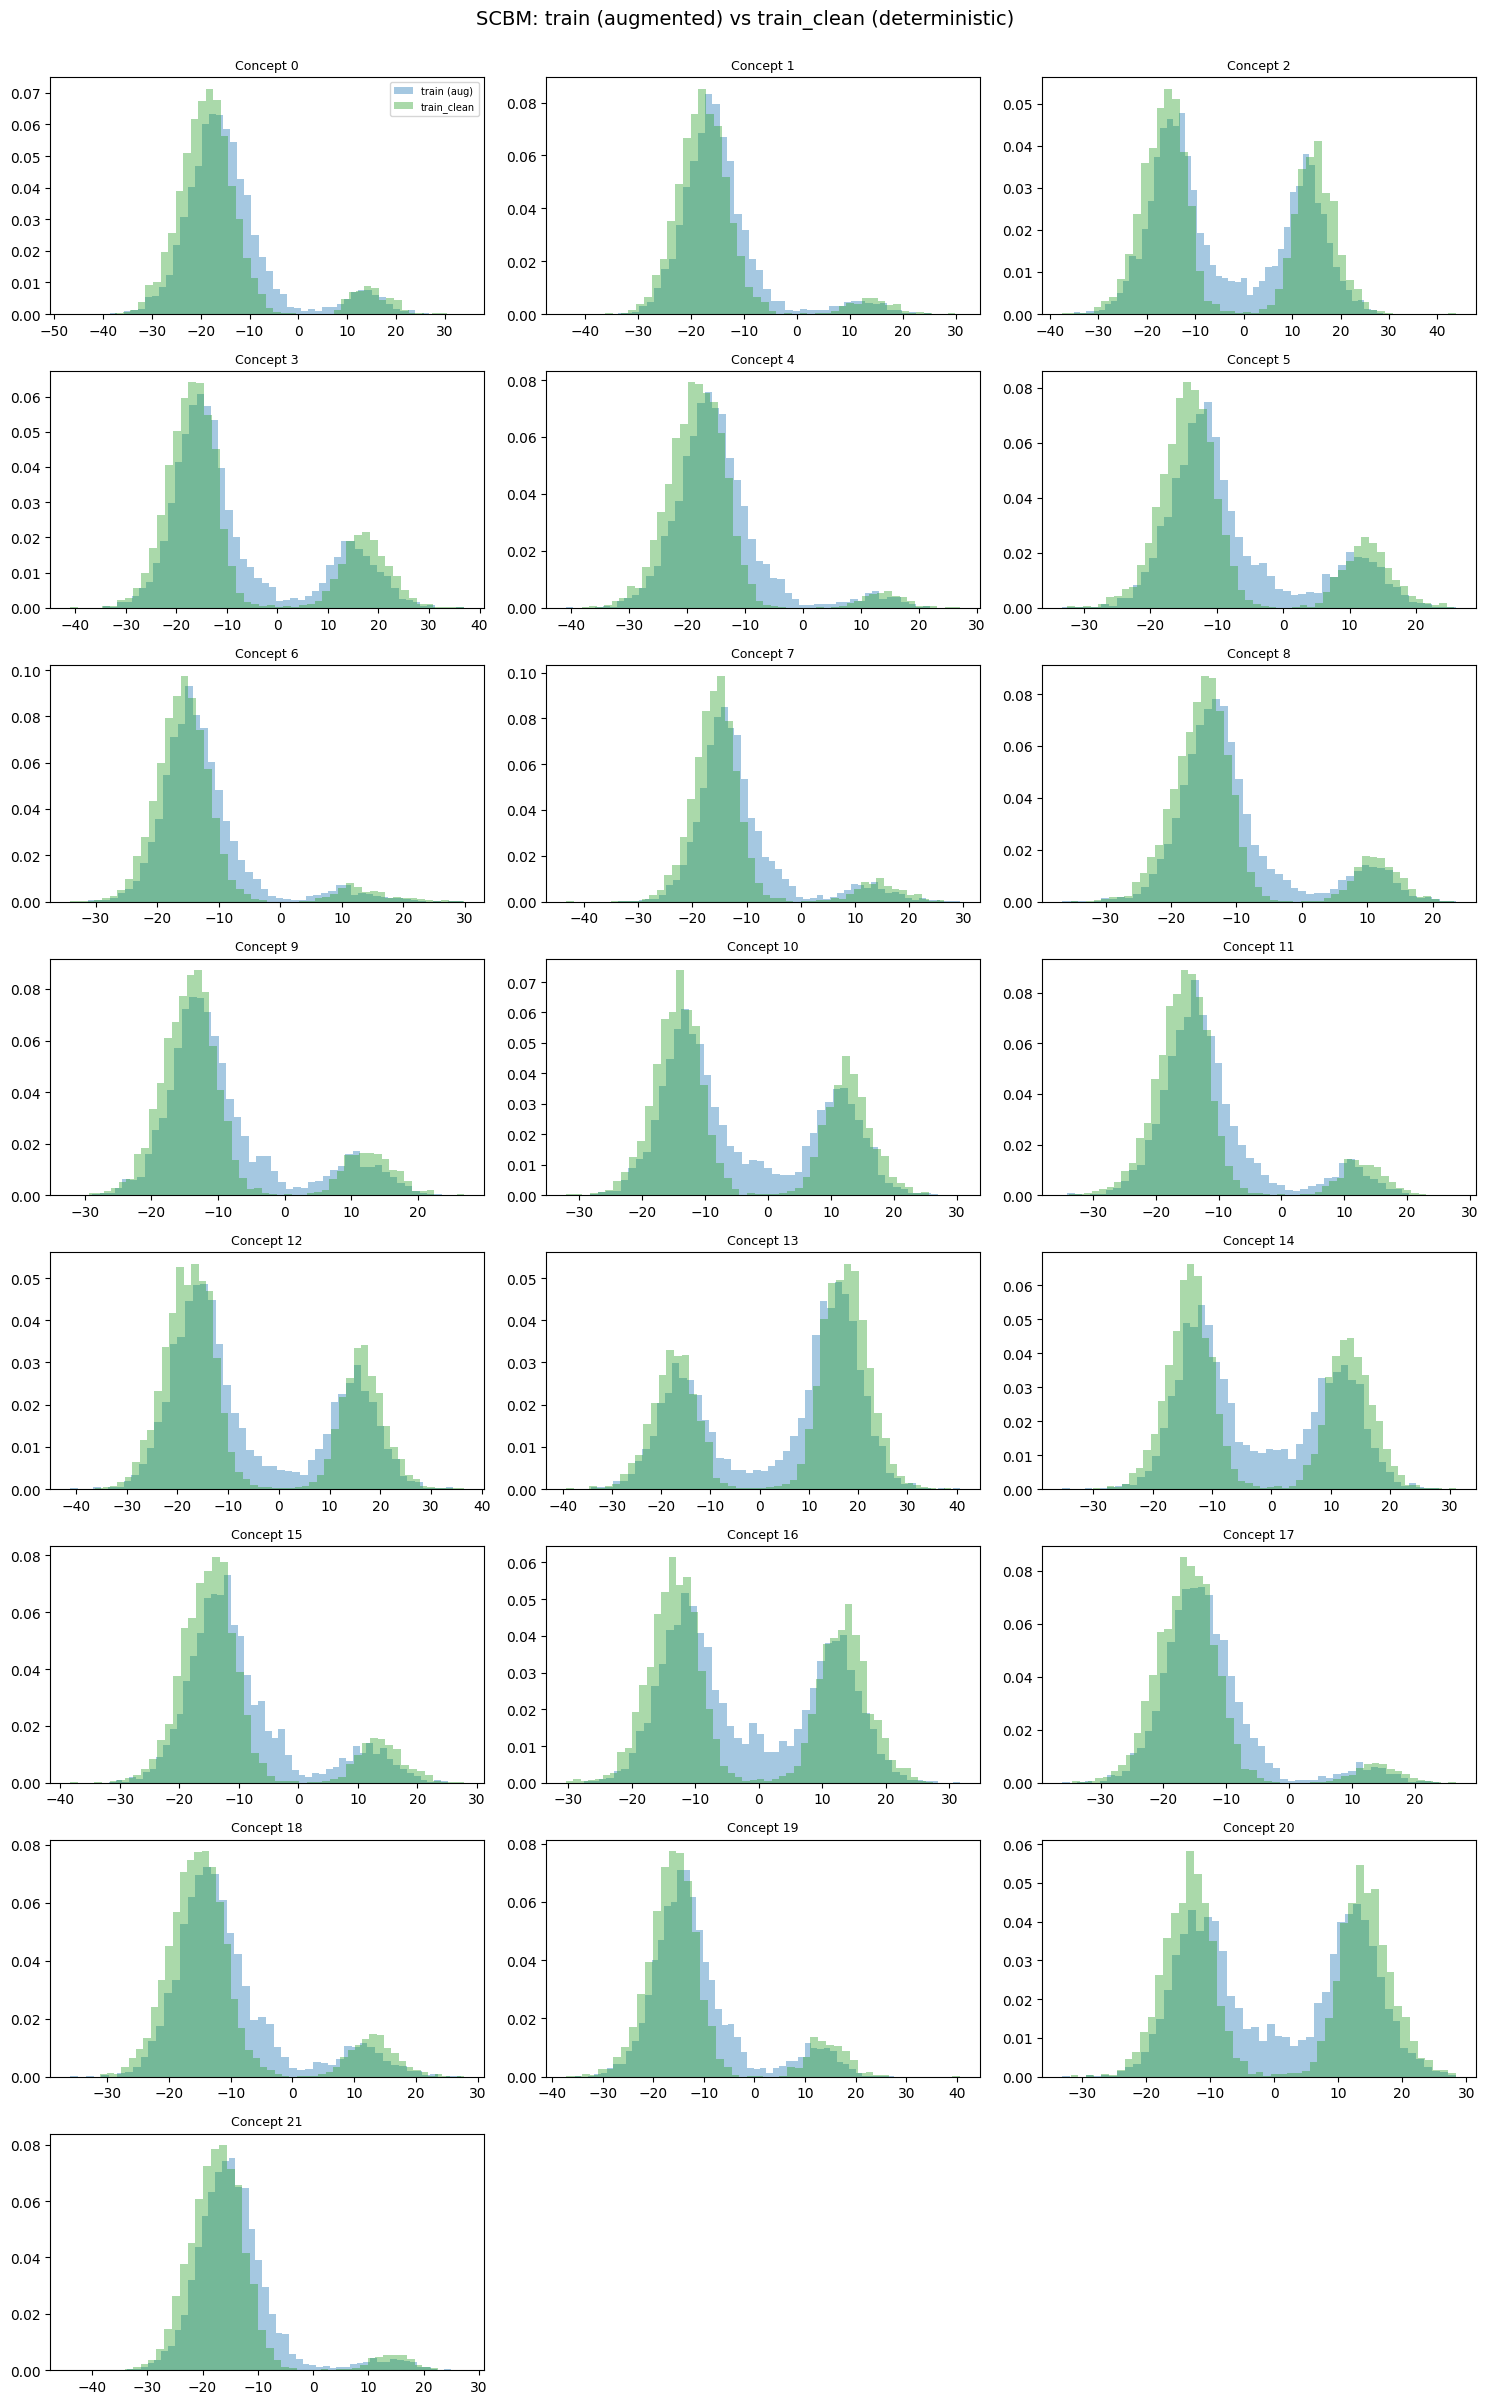

In [49]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic), per concept
num_cols = 3
num_rows = math.ceil(num_dims_scbm / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_scbm):
    ax = axes[i]
    label = f"Concept {i}"
    ax.hist(scbm_train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(scbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_scbm:]:
    ax.axis("off")

fig.suptitle("SCBM: train (augmented) vs train_clean (deterministic)", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

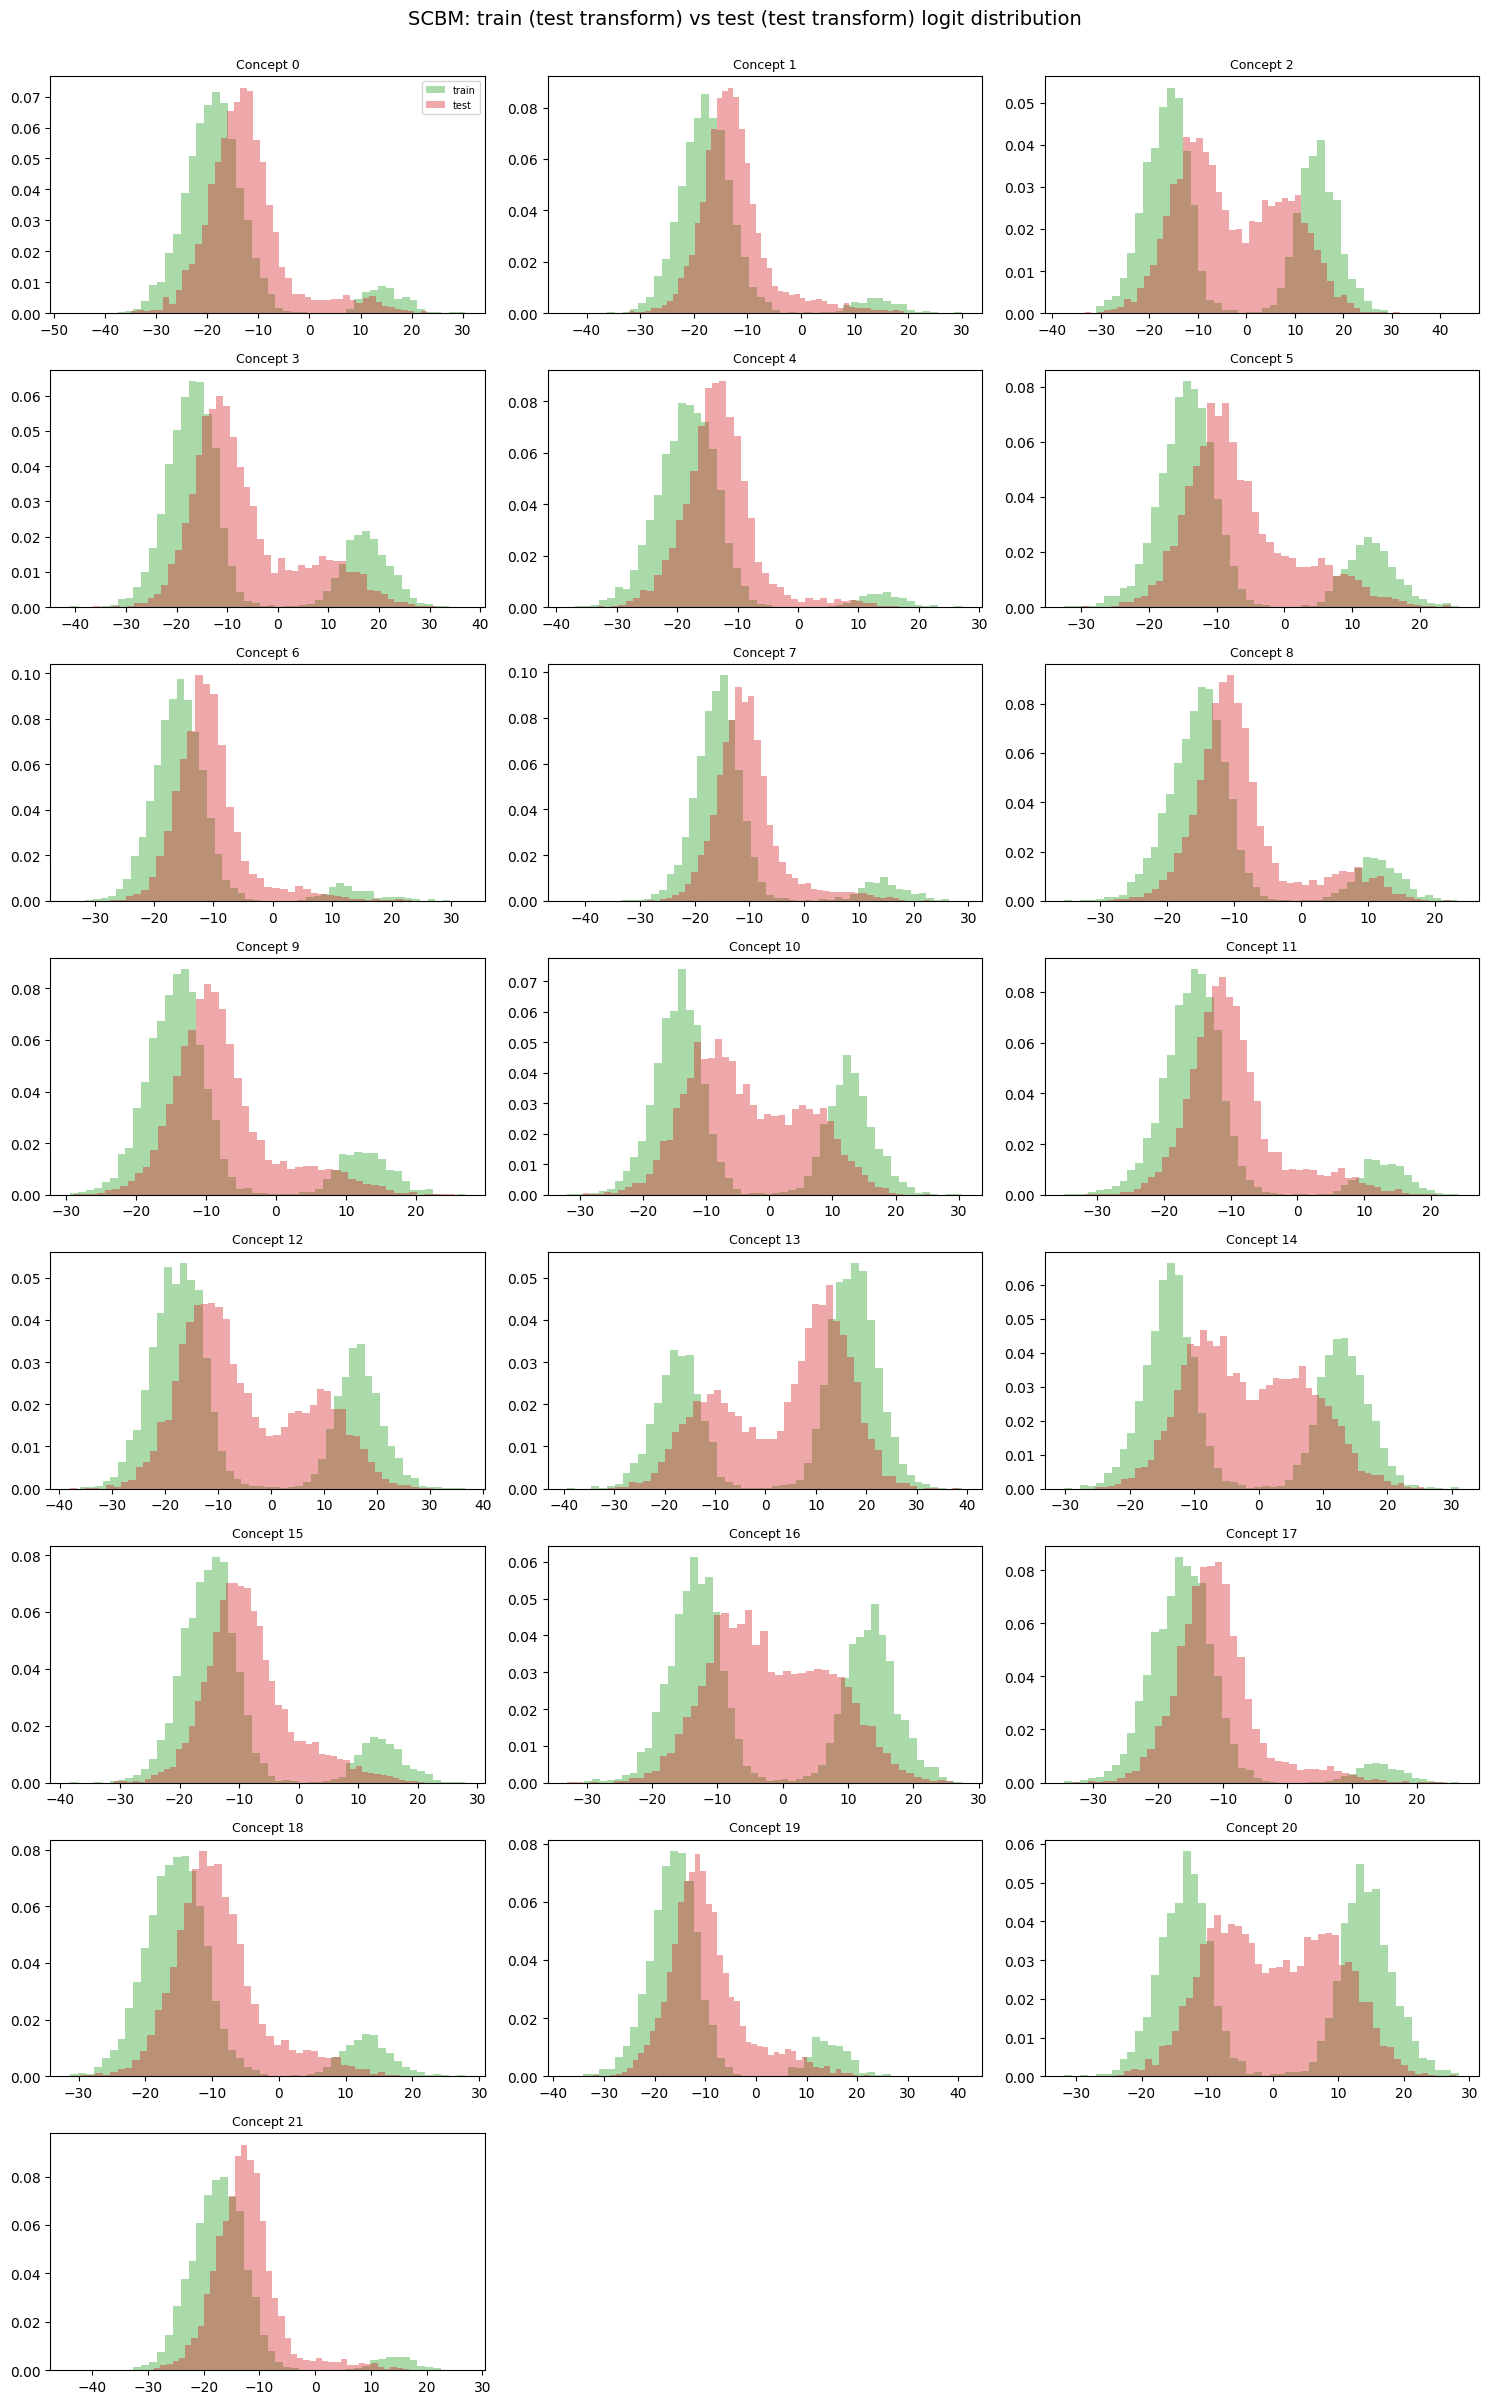

In [50]:
# Overlaid histograms: train_clean (deterministic) vs test, per concept
num_cols = 3
num_rows = math.ceil(num_dims_scbm / num_cols)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_scbm):
    ax = axes[i]
    label = f"Concept {i}"
    ax.hist(scbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(scbm_test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_scbm:]:
    ax.axis("off")

fig.suptitle("SCBM: train (test transform) vs test (test transform) logit distribution", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

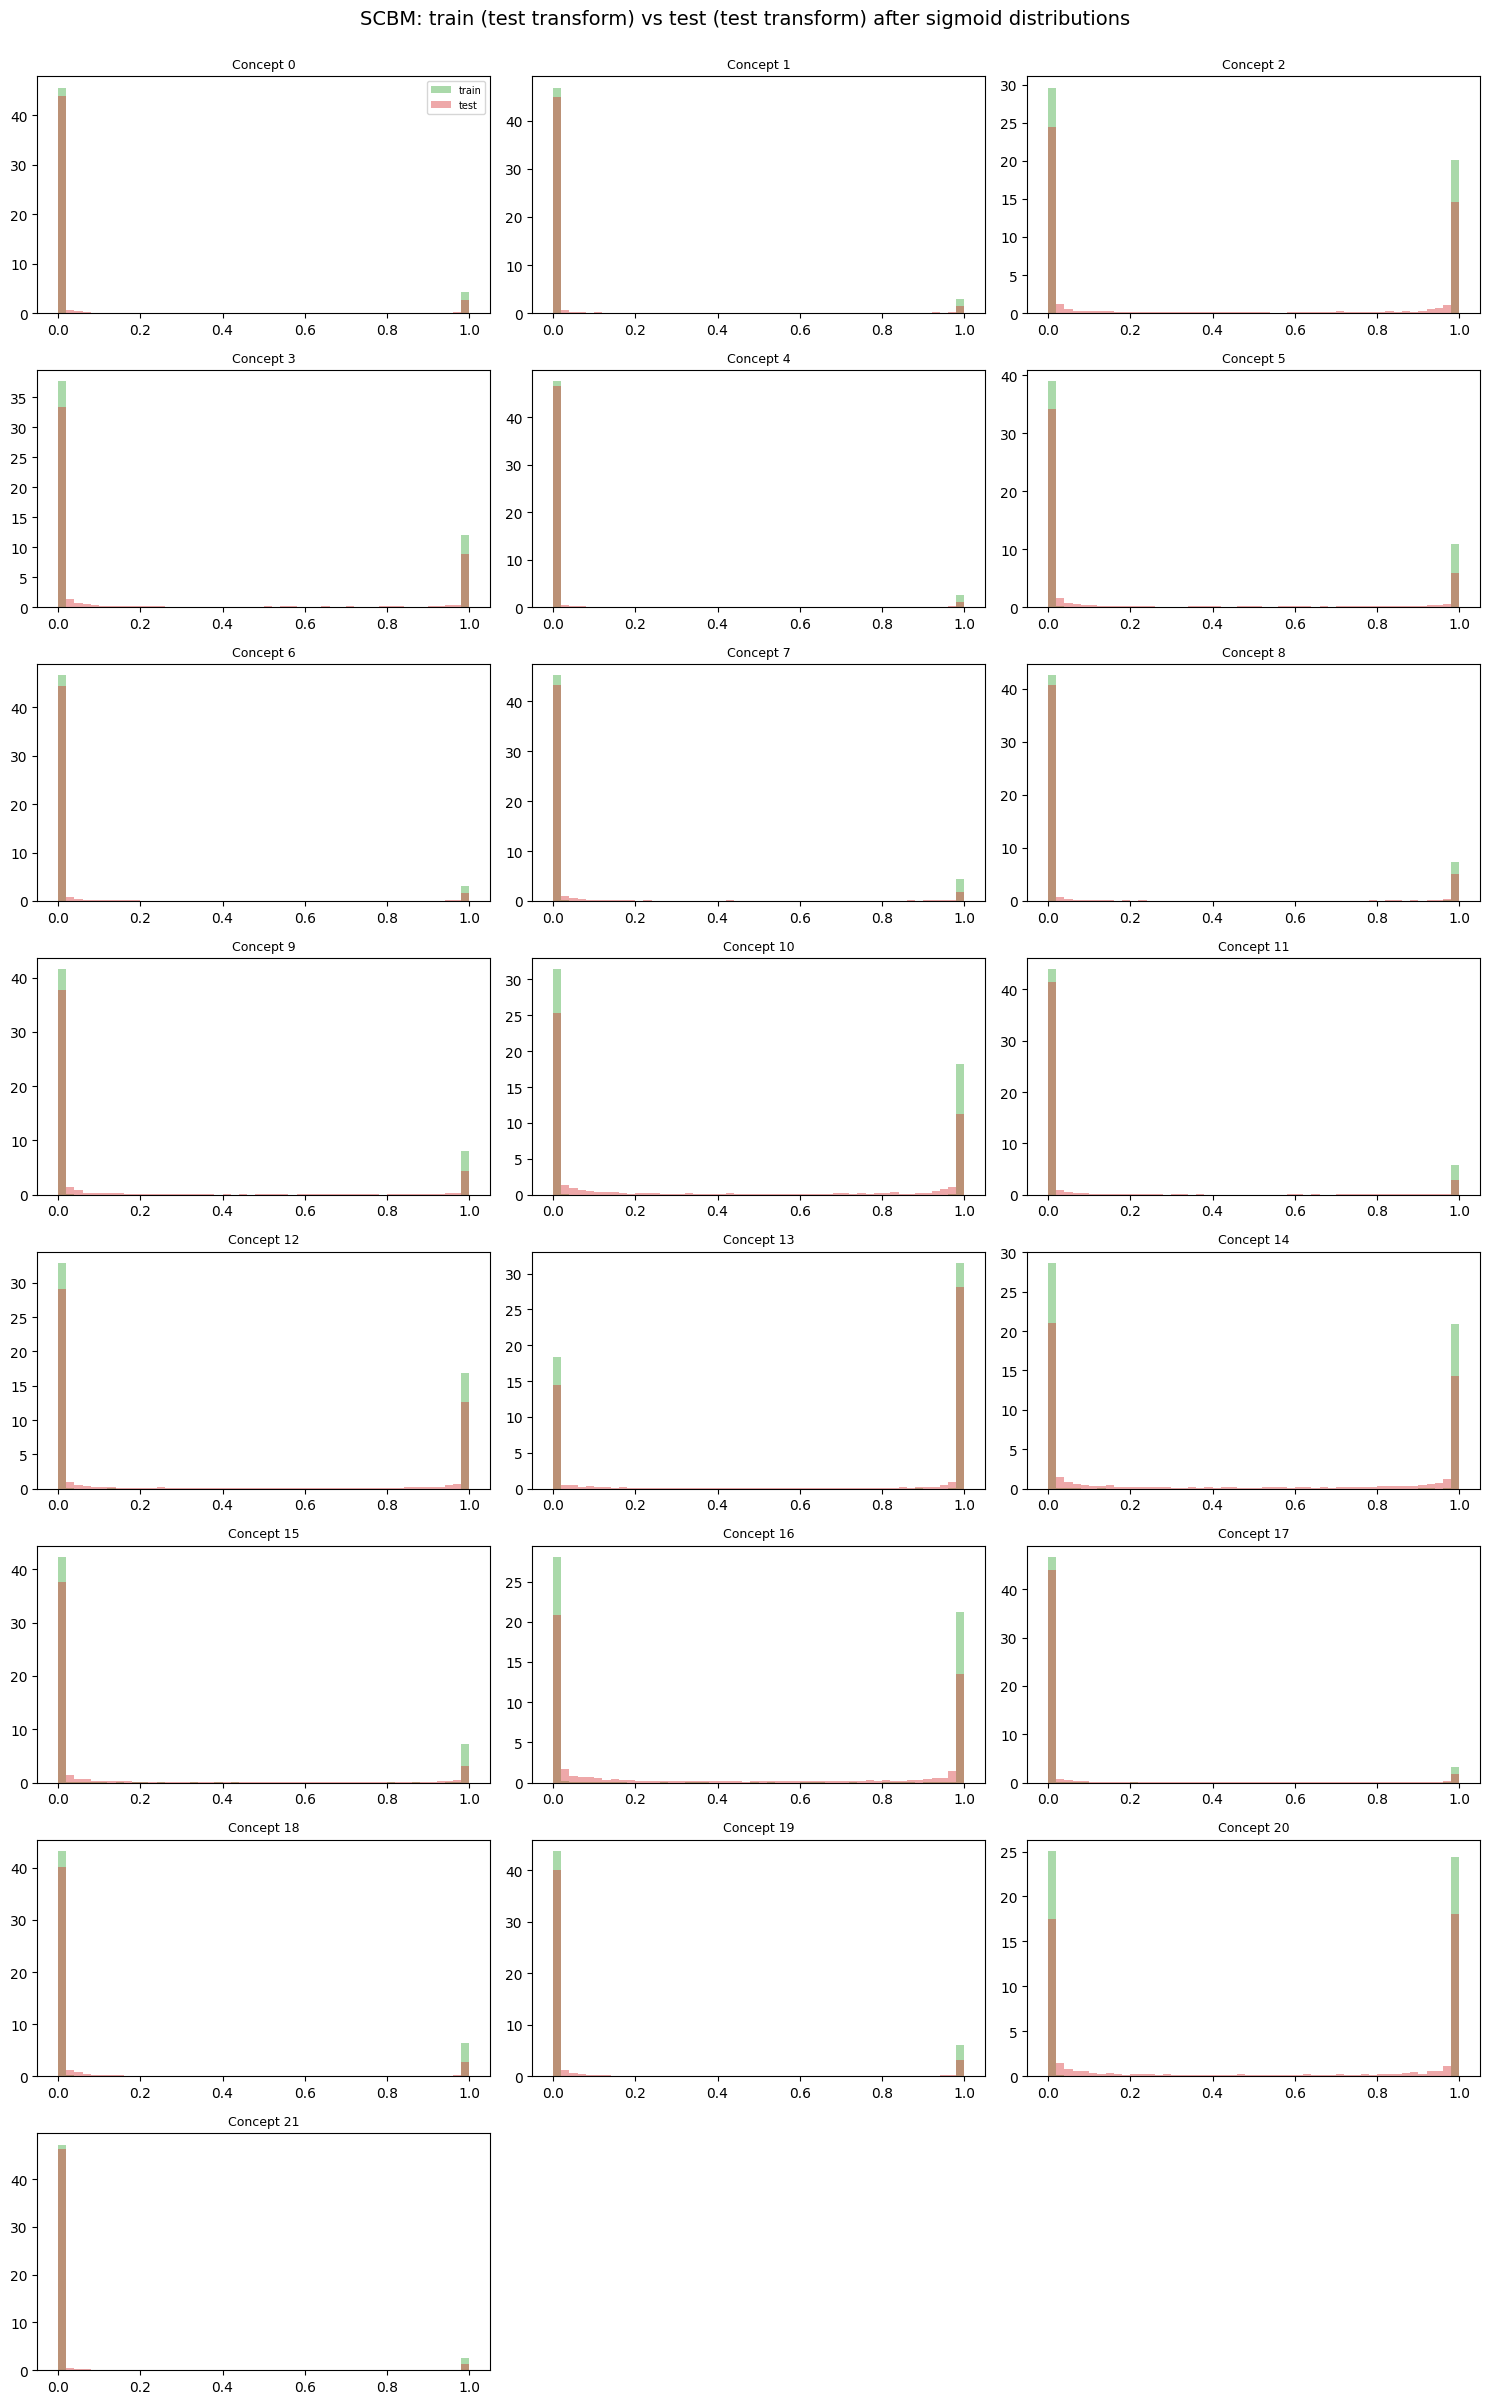

In [51]:
# Plot after sigmoid distributions for SCBM
scbm_train_probs = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train", "concepts_pred_probs_mean.pt"))
scbm_train_clean_probs = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_pred_probs_mean.pt"))
scbm_test_clean_probs = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, "test", "concepts_pred_probs_mean.pt"))   

# Overlaid histograms: train_clean (deterministic) vs test, per concept
num_cols = 3
num_rows = math.ceil(num_dims_scbm / num_cols)


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_scbm):
    ax = axes[i]
    label = f"Concept {i}"
    ax.hist(scbm_train_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(scbm_test_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_scbm:]:
    ax.axis("off")

fig.suptitle("SCBM: train (test transform) vs test (test transform) after sigmoid distributions", y=1.0, fontsize=14)
plt.tight_layout()


## Concept accuracy and AUROC across splits (including train_clean)

Same metrics as the Residual-SCBM section above (`utils/training.py`'s `Custom_Metrics.compute`
for `c_accuracy` / `complete_c_accuracy`, `utils/metrics.py`'s `calc_concept_metrics` for the
macro-averaged per-concept `c_AUROC`), computed here from the plain SCBM run's
`concepts_pred_probs_mean.pt` artifacts (no residual channel, so no slicing off residual dims
beyond the concept count).

In [52]:
from sklearn.metrics import roc_auc_score

splits_to_check = {
    "train": "train",
    "train_with_test_transform": "train",  # same underlying images as train, deterministic transform
    "val": "val",
    "test": "test",
}

scbm_concept_metrics_rows = []
for folder_name, pkl_split in splits_to_check.items():
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{pkl_split}.pkl"))
    c_true = np.array([sample["attribute_label"] for sample in data_pkl])

    c_probs_split = torch.load(os.path.join(SCBM_EXPERIMENT_PATH, folder_name, "concepts_pred_probs_mean.pt"))
    c_pred_probs = c_probs_split[:, :NUM_CONCEPTS_SCBM].numpy()
    c_pred = c_pred_probs > 0.5

    c_accuracy = (c_true == c_pred).mean()
    complete_c_accuracy = (c_true == c_pred).all(axis=1).mean()
    per_concept_auroc = [roc_auc_score(c_true[:, j], c_pred_probs[:, j]) for j in range(NUM_CONCEPTS_SCBM)]
    c_auroc = float(np.mean(per_concept_auroc))

    scbm_concept_metrics_rows.append({
        "split": folder_name,
        "n_samples": c_true.shape[0],
        "c_accuracy": c_accuracy,
        "complete_c_accuracy": complete_c_accuracy,
        "c_AUROC": c_auroc,
    })

scbm_concept_metrics_df = pd.DataFrame(scbm_concept_metrics_rows).set_index("split")
display(scbm_concept_metrics_df)

,n_samples,c_accuracy,complete_c_accuracy,c_AUROC
split,,,,
train,4796,0.988864,0.908882,0.999132
train_with_test_transform,4796,0.999242,0.993536,0.999990
val,1198,0.942973,0.512521,0.970224
test,5794,0.945351,0.532965,0.970307


## CBM concept distribution analysis

Baseline Hard CBM trained on the same reduced 22-concept `Mateo_025` CUB dataset as the SCBM/Residual-SCBM runs above, for direct comparison.

Requires the run to have been produced with:
```
python inference.py +model=CBM +data=CUB inference.ex_name=<run_folder_name> \
    run_inference=True incomplete=True data.pkl_file_dir=Mateo_025/ \
    data.num_concepts=22 data.num_classes=200 model.concept_learning=hard \
    data.save_concept_and_residual_channel=True
```
which writes `concepts_pred_probs.pt`, `concepts_logits.pt`, `concepts_sample_mean.pt`, `concepts_sample_std.pt`, `y_pred.pt`, `y_true.pt` per split (`train`, `val`, `test`, `train_with_test_transform`).

In [53]:
# Update this once the CBM run has been trained + inference has been run with save_concept_and_residual_channel=True
CBM_EXPERIMENT_PATH = os.path.join("experiments", "cbm", "CUB", "Mateo_025_2026-08-03_20-58-31_fe8e0")
NUM_CONCEPTS_CBM = 22

In [54]:
# Load test-split concepts/predictions
split = "test"
cbm_c_probs = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_pred_probs.pt"))
cbm_c_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_logits.pt"))
cbm_c_sample_mean = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "concepts_sample_mean.pt"))
cbm_y_true = torch.load(os.path.join(CBM_EXPERIMENT_PATH, split, "y_true.pt"))
cbm_c_binarized = (cbm_c_probs > 0.5).float()

print("cbm_c_probs shape:", cbm_c_probs.shape)
print("cbm_c_logits shape:", cbm_c_logits.shape)

unique_bin, counts_bin = torch.unique(cbm_c_binarized, return_counts=True)
print("Unique binary samples and their counts:")
for u, c in zip(unique_bin, counts_bin):
    print(f"  {u}: {c}")

cbm_c_probs shape: torch.Size([5794, 22])
cbm_c_logits shape: torch.Size([5794, 22])
Unique binary samples and their counts:
  0.0: 101253
  1.0: 26215


### Train (augmented) vs train (clean) vs test logit distribution comparison

Same augmentation-shift check as the SCBM plots above: `train` logits are computed with training-time augmentation, `train_with_test_transform` with the deterministic test-time transform on the same images, so any spread between the two isolates the augmentation effect from a genuine train/test distribution shift.

In [55]:
cbm_train_aug_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train", "concepts_logits.pt"))
cbm_train_clean_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_logits.pt"))
cbm_test_clean_logits = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "test", "concepts_logits.pt"))

print("train (augmented):", cbm_train_aug_logits.shape, "mean", cbm_train_aug_logits.mean().item(), "std", cbm_train_aug_logits.std().item())
print("train_clean (deterministic):", cbm_train_clean_logits.shape, "mean", cbm_train_clean_logits.mean().item(), "std", cbm_train_clean_logits.std().item())
print("test (deterministic):", cbm_test_clean_logits.shape, "mean", cbm_test_clean_logits.mean().item(), "std", cbm_test_clean_logits.std().item())

train (augmented): torch.Size([4796, 22]) mean -6.526349067687988 std 9.518078804016113
train_clean (deterministic): torch.Size([4796, 22]) mean -7.261409759521484 std 10.418976783752441
test (deterministic): torch.Size([5794, 22]) mean -6.2541303634643555 std 7.77667760848999


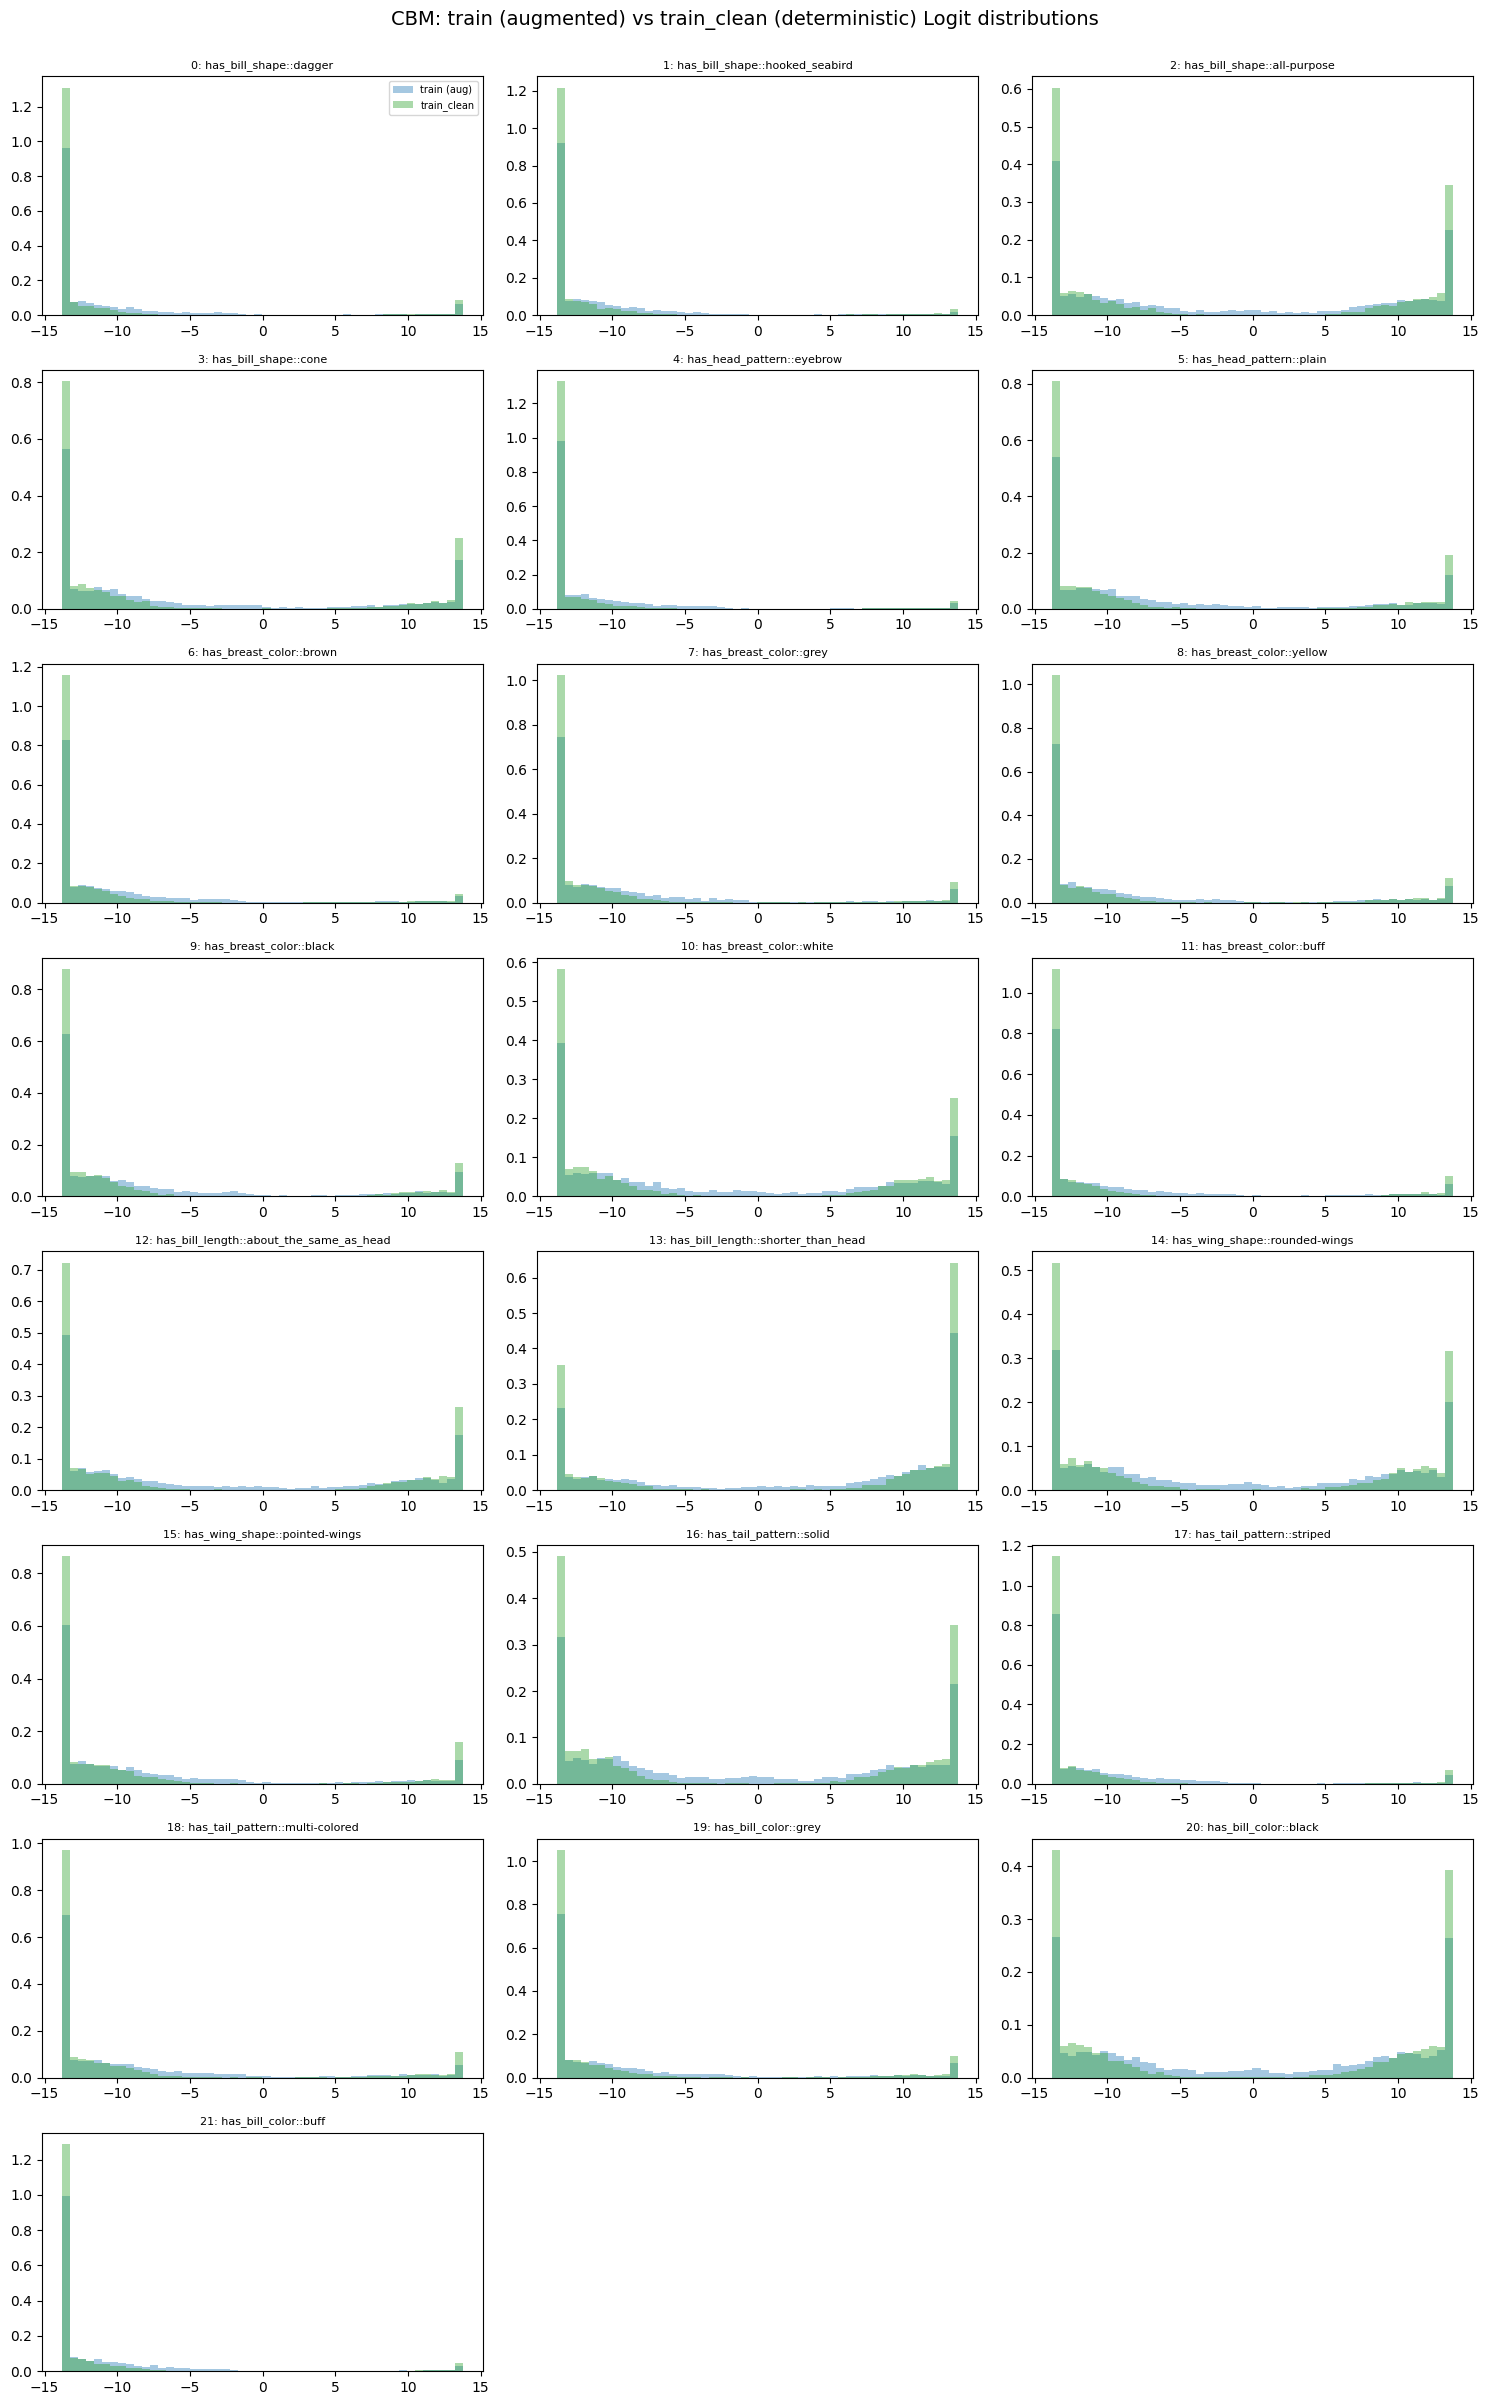

In [56]:
# Overlaid histograms: train (augmented) vs train_clean (deterministic), per concept
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_train_aug_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train (aug)", color="tab:blue")
    ax.hist(cbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train_clean", color="tab:green")
    ax.set_title(f"{i}: {name}", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle("CBM: train (augmented) vs train_clean (deterministic) Logit distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

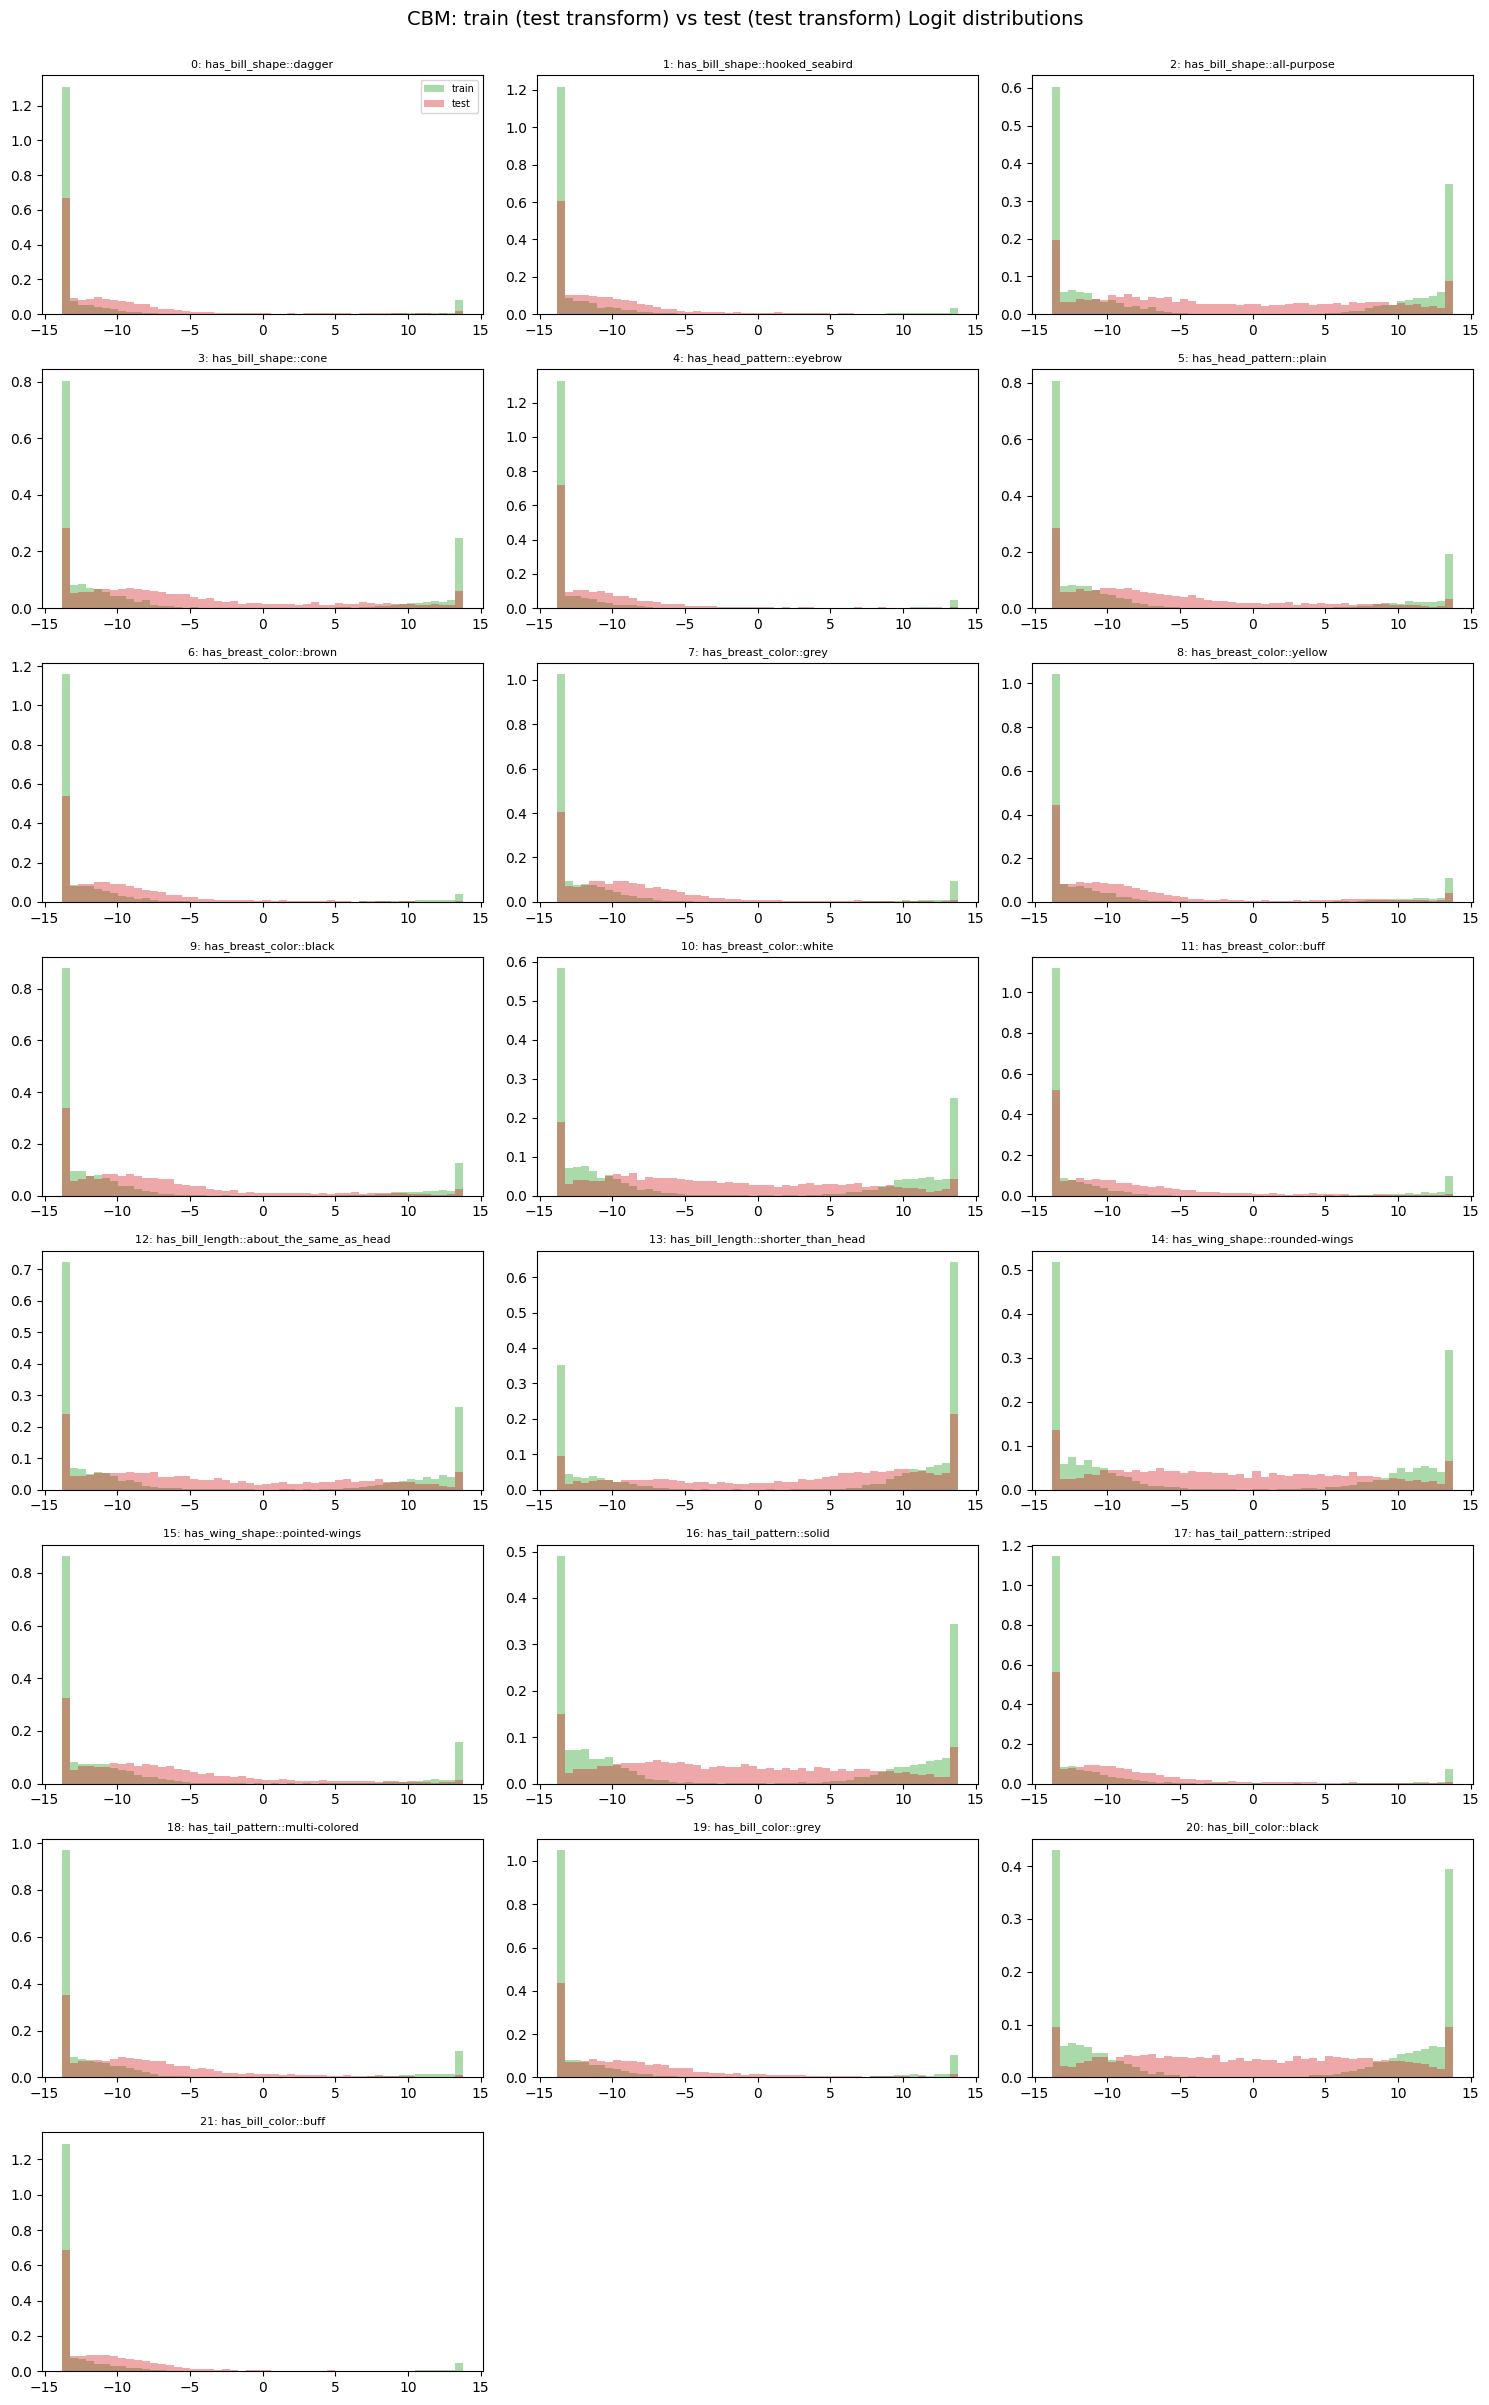

In [57]:
# Overlaid histograms: train_clean (deterministic) vs test, per concept
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(NUM_CONCEPTS_CBM):
    ax = axes[i]
    name = concept_names_new_idx_map.get(i, f"Concept {i}")
    ax.hist(cbm_train_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(cbm_test_clean_logits[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(f"{i}: {name}", fontsize=8)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[NUM_CONCEPTS_CBM:]:
    ax.axis("off")

fig.suptitle("CBM: train (test transform) vs test (test transform) Logit distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

train_probs shape: torch.Size([4796, 22])


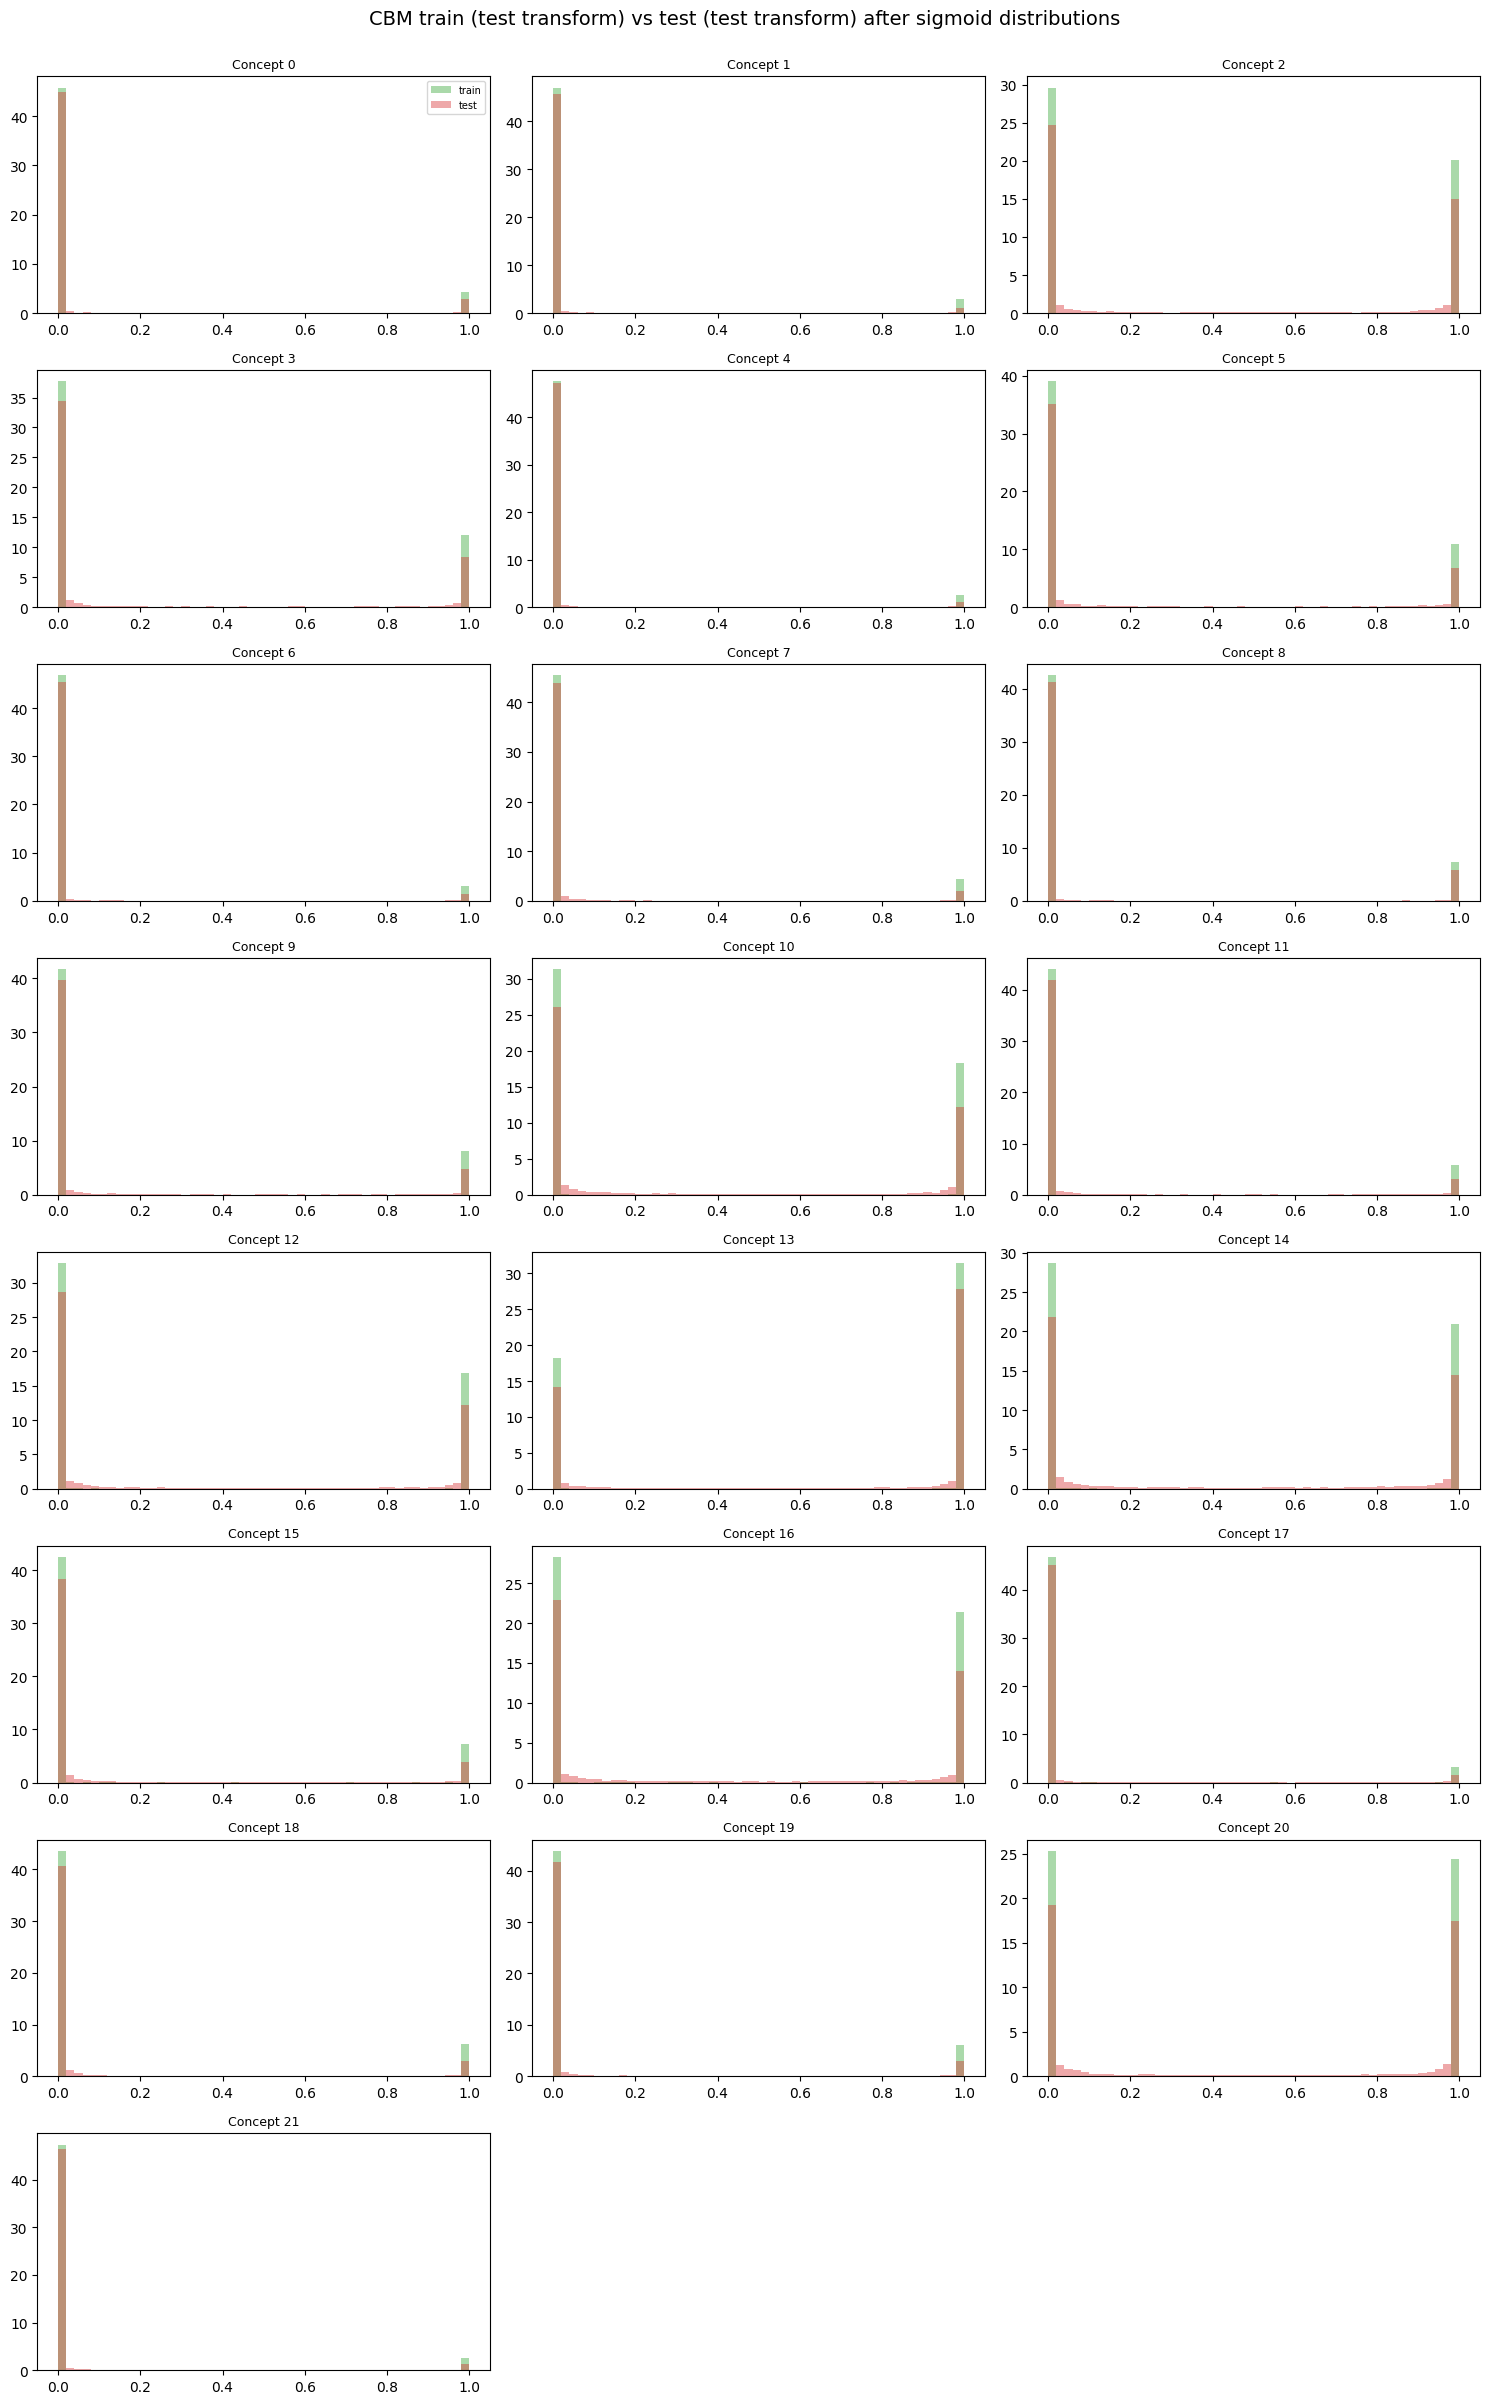

In [58]:
# Do the same for the probabilities (after sigmoid)
# load test probabilities
train_probs = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train", "concepts_pred_probs.pt"))
train_clean_probs = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "train_with_test_transform", "concepts_pred_probs.pt"))
test_clean_probs = torch.load(os.path.join(CBM_EXPERIMENT_PATH, "test", "concepts_pred_probs.pt"))
print("train_probs shape:", train_probs.shape)


# Overlaid histograms:train_clean (deterministic) vs test, per dimension
num_dims_cbm = train_probs.shape[1]
num_cols = 3
num_rows = math.ceil(num_dims_cbm / num_cols)


fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 3 * num_rows))
axes = axes.flatten()

for i in range(num_dims_cbm):
    ax = axes[i]
    is_concept = i < NUM_CONCEPTS_CBM
    label = f"Concept {i}" if is_concept else f"Residual {i - NUM_CONCEPTS_CBM}"
    ax.hist(train_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="train", color="tab:green")
    ax.hist(test_clean_probs[:, i].numpy(), bins=50, density=True, alpha=0.4, label="test", color="tab:red")
    ax.set_title(label, fontsize=9)
    if i == 0:
        ax.legend(fontsize=7)

for ax in axes[num_dims_cbm:]:
    ax.axis("off")

fig.suptitle("CBM train (test transform) vs test (test transform) after sigmoid distributions", y=1.0, fontsize=14)
plt.tight_layout()
plt.show()

## Concept accuracy and AUROC across splits (including train_clean)

Reproduces `c_accuracy` / `complete_c_accuracy` (`utils/training.py`'s `Custom_Metrics.compute`) and macro-averaged per-concept `c_AUROC` (`utils/metrics.py`'s `calc_concept_metrics`) directly from the CBM run's saved `concepts_pred_probs.pt` artifacts, using concept ground truth (`attribute_label`) read from the same pkl files used for the `y_true` order check below. `train_with_test_transform` reuses the train split's pkl (same underlying images, just the deterministic transform instead of augmentation).

In [59]:
from sklearn.metrics import roc_auc_score

splits_to_check = {
    "train": "train",
    "train_with_test_transform": "train",  # same underlying images as train, deterministic transform
    "val": "val",
    "test": "test",
}

cbm_concept_metrics_rows = []
for folder_name, pkl_split in splits_to_check.items():
    data_pkl = pd.read_pickle(os.path.join("datasets", "CUB", "incomplete_data", "Mateo_025", f"{pkl_split}.pkl"))
    c_true = np.array([sample["attribute_label"] for sample in data_pkl])

    c_probs_split = torch.load(os.path.join(CBM_EXPERIMENT_PATH, folder_name, "concepts_pred_probs.pt"))
    c_pred_probs = c_probs_split[:, :NUM_CONCEPTS_CBM].numpy()
    c_pred = c_pred_probs > 0.5

    c_accuracy = (c_true == c_pred).mean()
    complete_c_accuracy = (c_true == c_pred).all(axis=1).mean()
    per_concept_auroc = [roc_auc_score(c_true[:, j], c_pred_probs[:, j]) for j in range(NUM_CONCEPTS_CBM)]
    c_auroc = float(np.mean(per_concept_auroc))

    cbm_concept_metrics_rows.append({
        "split": folder_name,
        "n_samples": c_true.shape[0],
        "c_accuracy": c_accuracy,
        "complete_c_accuracy": complete_c_accuracy,
        "c_AUROC": c_auroc,
    })

cbm_concept_metrics_df = pd.DataFrame(cbm_concept_metrics_rows).set_index("split")
display(cbm_concept_metrics_df)

,n_samples,c_accuracy,complete_c_accuracy,c_AUROC
split,,,,
train,4796,0.991413,0.923478,0.999451
train_with_test_transform,4796,0.999024,0.991034,0.999979
val,1198,0.938610,0.479132,0.967828
test,5794,0.941632,0.503452,0.967640
